In [3]:
#%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar

# Setting Up

## Most Basic: Functions and Variables

In [4]:
epsilon_0 = 1 #8.854E-12 # F/m
mu_0 = 1 #np.pi*4.0E-7 # H/m
c = 1 #3.0E08 # m/s
lam0 = 450e-9+0.0j
#h0 = h1
theta0 = np.pi/6
h1 = 10e-9
n0 = 1.0+0.0j
n1 = 1.5+0.0j
e_x = np.array([1.0+0.0j,0.0+0.0j,0.0+0.0j])
e_y = np.array([0.0+0.0j,1.0+0.0j,0.0+0.0j])
e_z = np.array([0.0+0.0j,0.0+0.0j,1.0+0.0j])
norm_vec = e_z

def TtoS(mat):  # to scattering matrix, diagonal terms are reflection coefficients.
    [[m11,m12],[m21,m22]]=mat
    [[r12,t21],[t12,r21]]=[[-m21/m22,1/m22],[m11-m12*m21/m22,m12/m22]]
    return np.array([[r12,t21],[t12,r21]])

def StoT(co):  # to transfer matrix, 
    [[r12,t21],[t12,r21]]=co
    [[m11,m12],[m21,m22]]=[[(t12- r12*r21/t21),r21/t21],[-r12/t21,1/t21]]
    return np.array([[m11,m12],[m21,m22]])

def totalST(layers):
    t=np.identity(2)
    for lay in layers:
        t0=StoT(lay)
        t=t0@t
    s=TtoS(t)
    return s,t    

Recall that the T matrices are not causal. You do not have a simple physical input-output relation. You need to know the future in order to be able to use them. Meanwhile, the S matrices are causal: you give input fields anf get output fields.

The refraction plane is the x-z plane, i.e. an s-polarised wave has the E field pointing along y and a p-polarised wave has the E field pointing along x.

## EM Wave

In [5]:
def k_vector(k_mag,theta=0):
    k_vec = k_mag*np.array([np.sin(theta),0,np.cos(theta)])
    return k_vec

def k_vector_multi(k_values,theta=0):
    k_vecs = k_values[:,np.newaxis]*np.array([np.sin(theta),0,np.cos(theta)])
    return k_vecs

def k_vector_multi_reflect(k_values,theta=0):
    k_vecs = k_values[:,np.newaxis]*np.array([np.sin(theta),0,-np.cos(theta)])
    return k_vecs
               
def k_j(ki,ni,nj):
    kj = np.array([ki[0],ki[1],np.sqrt(ki[2]**2+np.dot(ki,ki.conj())*((nj/ni)**2-1))])
    return kj

def k_j_multi(kis,ni,nj):
    kjs = np.transpose(np.array([kis[:,0],kis[:,1],np.sqrt(kis[:,2]**2+np.sum(kis*kis.conj(),axis=1)*((nj/ni)**2-1))]))
    return kjs

def gen_E_amp(E_par,E_perp):
    if E_par == 0 and E_perp == 0:
        return np.array([complex(E_par),complex(E_perp),0.0+0.0j])
    else:
        return 1/np.sqrt(np.abs(E_par)**2+np.abs(E_perp)**2)*np.array([complex(E_par),complex(E_perp),0.0+0.0j])

def E_avi_decomp(E_avi,ki):
    E_avsi = E_avi[1] * e_y
    E_avpi = E_avi[0] * np.cross(e_y,ki/np.sqrt(np.dot(ki,ki)))
    #proper_E_avi = E_avsi + E_avpi
    return E_avsi,E_avpi

def mag_field(k_values, E_3d_k,theta=0):
    u_dir = np.array([np.sin(theta),0,np.cos(theta)],dtype=np.complex128)
    ki3ds = np.einsum('i,j->ij',k_values,u_dir)
    return -1 / (mu_0 * c) * np.einsum('i,ik->ik',1/k_values,np.cross(ki3ds, E_3d_k))

def mag_field_rev(k_values, E_3d_k,theta=0):
    u_dir = np.array([np.sin(theta),0,-np.cos(theta)],dtype=np.complex128)
    ki3ds = np.einsum('i,j->ij',k_values,u_dir)
    return -1 / (mu_0 * c) * np.einsum('i,ik->ik',1/k_values,np.cross(ki3ds, E_3d_k))

ki0 = k_vector(np.array(2*np.pi/lam0),theta0)

## System

### Elements and Periods

In [6]:
def medium(k_vec,h):  # scattering matrix, diagonal terms are reflection coefficients.
    # k_vec is a 3D vector
    rij=0
    rji=0
    tij=np.exp(1j*k_vec[2]*h)
    tji=np.exp(1j*k_vec[2]*h)
    return np.array([[rij,tji],[tij,rji]])

def interface_s(ki,kj):  # scattering matrix, s-polarised, diagonal terms are reflection coefficients.
    kzi = ki[2]
    kzj = kj[2]
    if np.iscomplex(kzj):
        raise ValueError("Total internal reflection going ij")
    rij = (kzi - kzj)/(kzi + kzj)
    rji = -rij
    tij = 1 + rij #2*kzi/(kzi + kzj)
    tji = 1 + rji #2*kzj/(kzi + kzj)
    # print(1/kzi*(kzi*np.abs(rij)**2+kzj*np.abs(tij)**2))
    # print(1/kzj*(kzj*np.abs(rji)**2+kzi*np.abs(tji)**2))
    return np.array([[rij,tji],[tij,rji]])

def interface_p(ki,kj):  # scattering matrix, p-polarised, diagonal terms are reflection coefficients.
    kzi = ki[2]
    kzj = kj[2]
    ki_a = np.sqrt(np.dot(ki,ki.conj()))
    kj_a = np.sqrt(np.dot(kj,kj.conj()))
    if np.iscomplex(kzj):
        raise ValueError("Total internal reflection going ij")
    rij = (kzi/ki_a**2 - kzj/kj_a**2)/(kzi/ki_a**2 + kzj/kj_a**2)
    rji = -rij
    tij = 2*kzi/((kj_a/ki_a)*kzi + (ki_a/kj_a)*kzj)
    tji = kzj/kzi * tij # 2*kzj/((ni/nj)*kzj + (nj/ni)*kzi)
    # print(1/kzi*(kzi*np.abs(rij)**2+kzj*np.abs(tij)**2))
    # print(1/kzj*(kzj*np.abs(rji)**2+kzi*np.abs(tji)**2))
    return np.array([[rij,tji],[tij,rji]])

def m_p(ki,kj,hi,hj):
    layers_p =[medium(ki,hi/2),interface_p(ki,kj),medium(kj,hj),interface_p(kj,ki),medium(ki,hi/2)]
    sp,mp = totalST(layers_p) 
    #print(np.abs(sp[0][0])**2+np.abs(sp[0][1])**2)
    #print(np.abs(sp[1][0])**2+np.abs(sp[1][1])**2)
    return sp,mp,layers_p

def m_s(ki,kj,hi,hj):
    layers_s =[medium(ki,hi/2),interface_s(ki,kj),medium(kj,hj),interface_s(kj,ki),medium(ki,hi/2)]
    ss,ms = totalST(layers_s)
    #print(np.abs(ss[0][0])**2+np.abs(ss[0][1])**2)
    #print(np.abs(ss[1][0])**2+np.abs(ss[1][1])**2)
    return ss,ms,layers_s

### Effectives

In [7]:
def eff_n(ki,perM,hi,hj):
    evs = np.linalg.eig(perM)[0]
    kz = np.log(evs[0])/(1j*(hi+hj))
    neff = np.real(np.sqrt((ki[0]**2+ki[1]**2+kz**2)/np.dot(ki,ki.conj())))
    return neff

def reverse_eff_n(ki,neff,hi,hj):
    n_s = 0
    n_p = 0
    def find_n_s(n):
        return eff_n(ki,m_s(ki,k_j(ki,n0,n),hi,hj)[1],hi,hj)-neff
    n_s = root_scalar(find_n_s, bracket=[1,2*neff]).root
    def find_n_p(n):
        return eff_n(ki,m_p(ki,k_j(ki,n0,n),hi,hj)[1],hi,hj)-neff
    n_p = root_scalar(find_n_p, bracket=[1,2*neff]).root
    return n_s,n_p

def reverse_eff_nh(ki,neff,n,h):
    r_s = 0
    r_p = 0
    def find_rs(r):
        return eff_n(ki,m_s(ki,k_j(ki,n0,n),r*h,(1-r)*h)[1],r*h,(1-r)*h)-neff
    r_s = root_scalar(find_rs, bracket=[0,1]).root
    def find_rp(r):
        return eff_n(ki,m_p(ki,k_j(ki,n0,n),r*h,(1-r)*h)[1],r*h,(1-r)*h)-neff
    r_p = root_scalar(find_rp, bracket=[0,1]).root
    return r_s,r_p

### Composite Structure

In [8]:
def element_maker(ki,refrac_indices,widths,width_ratios):
    if len(refrac_indices) != len(widths) or len(widths)!= len(width_ratios):# or len(width_ratios) != len(nums):
        raise ValueError("Input lists must have the same length.")
        return
    elementss = []
    elementss_decomp = []
    elementsp = []
    elementsp_decomp = []
    neffs = []
    neffp = []
    for i in range(len(refrac_indices)):
        n = refrac_indices[i]
        w = widths[i]
        r = width_ratios[i]
        kj = k_j(ki,n0,n)
        hi = r*w
        hj = (1-r)*w
        ss,ms,layers_s = m_s(ki,kj,hi,hj)
        nes = eff_n(ki,ms,hi,hj)
        sp,mp,layers_p = m_p(ki,kj,hi,hj)
        nep = eff_n(ki,mp,hi,hj)
        elementss.append(ss)
        elementsp.append(sp)
        elementss_decomp.append(layers_s)
        elementsp_decomp.append(layers_p)
        neffs.append(nes)
        neffp.append(nep)
    return elementss,elementss_decomp,neffs,elementsp,elementsp_decomp,neffp

def embedded_structure(elements_s_form,num_elements):
    if len(elements_s_form) != len(num_elements):
        raise ValueError("elements_s_form and num_elements must have the same length.")
        return
    emb = 0
    for i in range(len(elements_s_form)):
        if i == 0:
            emb = np.tile(elements_s_form[i], (num_elements[i], 1, 1))
        else:
            emb = np.concatenate((emb, np.tile(elements_s_form[i], (num_elements[i], 1, 1))))
    return emb

## Fields

In [9]:
def amps_from_a0b0_pol(a0b0_proper_pol,elements,num_elements):
    emb = embedded_structure(elements,num_elements)
    aibi_pol = np.array([a0b0_proper_pol])
    m = np.eye(2)
    for i in range(len(emb)):
        m = StoT(emb[i])@m
        aibi_pol = np.append(aibi_pol, [m@(aibi_pol[0])], axis=0)
    ai_pol = aibi_pol[:,0]
    bi_pol = aibi_pol[:,1]
    return ai_pol,bi_pol

def amps_from_anbn_pol(anbn_proper_pol,elements,num_elements):
    emb = embedded_structure(elements,num_elements)
    aibi_pol = np.array([anbn_proper_pol])
    m = np.eye(2)
    for i in range(len(emb)-1,-1,-1):
        m = np.linalg.inv(StoT(emb[i]))@m
        aibi_pol = np.append(aibi_pol, [m@(aibi_pol[0])], axis=0)
    aibi_pol = aibi_pol[-1:0:-1,:]
    ai_pol = aibi_pol[:,0]
    bi_pol = aibi_pol[:,1]
    return ai_pol,bi_pol
    
def amps_from_els_pol(a0_pol,elements,num_elements):
    emb = embedded_structure(elements,num_elements)
    aibi_pol = np.array([np.linalg.eig(StoT(emb[-1]))[1][0]])
    m = np.eye(2)
    for i in range(len(emb)-1,-1,-1):
        m = np.linalg.inv(StoT(emb[i]))@m
        aibi_pol = np.append(aibi_pol, [m@(aibi_pol[0])], axis=0)
    aibi_pol = aibi_pol[-1:0:-1,:]/aibi_pol[-1][0]*a0_pol
    ai_pol = aibi_pol[:,0]
    bi_pol = aibi_pol[:,1]
    return ai_pol,bi_pol

def amps_from_els_pol_multi_k(a0_pol,k_values,refrac_indices,widths,width_ratios,num_elements,theta=0):
    ai_pol_k = np.empty((len(k_values),np.sum(5*num_elements)),dtype=np.complex128)
    bi_pol_k = np.empty((len(k_values),np.sum(5*num_elements)),dtype=np.complex128)
    for i in range(len(k_values)):
        ki = k_vector(k_values[i],theta)
        elementss,elementss_decomp,neffs,elementsp,elementsp_decomp,neffp = element_maker(ki,refrac_indices,widths,width_ratios)
        ai_pol,bi_pol = amps_from_els_pol(a0_pol,elementss_decomp,num_elements)
        ai_pol_k[i,:] = ai_pol
        bi_pol_k[i,:] = bi_pol
    return ai_pol_k,bi_pol_k

def gaussian_weighting(k_values, k_c=5, sigma=1.5):
    return 1/(np.sqrt(2*np.pi)*sigma)*np.exp(-0.5 * ((k_values - k_c) / sigma)**2)

def time_mod(k_values, t_values):
    return np.exp(-1j * np.outer(k_values, t_values) * c)

def amps_from_els_pol_multi_tk(a0_pol,k_values,t_values,refrac_indices,widths,width_ratios,num_elements,theta=0,k_c=5,sigma=1.5):
    weights_tk = np.transpose(gaussian_weighting(k_values[:,np.newaxis],k_c,sigma)*time_mod(k_values,t_values))
    ai_pol_k,bi_pol_k = amps_from_els_pol_multi_k(a0_pol,k_values,refrac_indices,widths,width_ratios,num_elements,theta)
    ai_pol_tk = weights_tk[:, :, np.newaxis]*ai_pol_k[np.newaxis, :, :]
    bi_pol_tk = weights_tk[:, :, np.newaxis]*bi_pol_k[np.newaxis, :, :]
    return ai_pol_tk,bi_pol_tk

def sto3d(ai_pol):
    ai_3d = np.transpose(np.array([np.zeros(len(ai_pol)),ai_pol,np.zeros(len(ai_pol))]))
    return ai_3d

def pxto3d(ai_pol):
    ai_3d = np.transpose(np.array([ai_pol,np.zeros(len(ai_pol)),np.zeros(len(ai_pol))]))
    return ai_3d

def pzto3d(ai_pol):
    ai_3d = np.transpose(np.array([np.zeros(len(ai_pol)),np.zeros(len(ai_pol)),ai_pol]))
    return ai_3d

def sto3d_multi_tk(ai_pol_tk):
    return np.einsum('jkl,i->jkli', ai_pol_tk, e_y)

def amps_from_els_3d(a0_3d,ki,s_elements,p_elements,num_elements):
    [a0px,a0s,a0pz] = E_avi_decomp(a0_3d,ki)[0]+E_avi_decomp(a0_3d,ki)[1] #a0_proper_3d 
    aipx,bipx = amps_from_els_pol(a0px,p_elements,num_elements)
    ais,bis = amps_from_els_pol(a0s,s_elements,num_elements)
    aipz,bipz = amps_from_els_pol(a0pz,p_elements,num_elements)
    ai_3d = np.transpose(np.array([aipx,ais,aipz]))
    bi_3d = np.transpose(np.array([bipx,bis,bipz]))
    return ai_3d,bi_3d

def plot_amps(ai,bi,time,num_elements):
    int_locs = np.cumsum(num_elements)[:-1]
    plt.figure()
    plt.xlabel('Layer Number')
    plt.ylabel('Intensity')
    plt.title('Intensity Across Layers t = ' + str(time) + ' time units')
    plt.plot(np.abs(ai)**2/np.max(np.abs(ai)**2), label='|a|^2')
    plt.plot(np.abs(bi)**2/np.max(np.abs(ai)**2), label='|b|^2')
    plt.plot(np.abs(ai+bi)**2/np.max(np.abs(ai)**2), label='|a+b|^2')
    for loc in int_locs:
        plt.axvline(loc,ls='--',c='k')
    plt.legend()
    plt.grid()
    plt.show()

def plot_amps_3d(ai_3d,bi_3d):
    plt.figure()
    plt.xlabel('Layer Number')
    plt.ylabel('Intensity')
    plt.title('Intensity Across Layers')
    plt.plot(np.abs(ai_3d[:,0])**2+np.abs(ai_3d[:,1])**2+np.abs(ai_3d[:,2])**2, label='|a|^2')
    plt.plot(np.abs(bi_3d[:,0])**2+np.abs(bi_3d[:,1])**2+np.abs(bi_3d[:,2])**2, label='|b|^2')
    plt.plot(np.abs(ai_3d[:,0]+bi_3d[:,0])**2+np.abs(ai_3d[:,1]+bi_3d[:,1])**2+np.abs(ai_3d[:,2]+bi_3d[:,2])**2, label='|a+b|^2')
    plt.legend()
    plt.grid()
    plt.show()

## Momentum

In [10]:
def mag_field_tk(k_values, Ei_3d_multi_tk,theta=0):
    u_dir = np.array([np.sin(theta),0,np.cos(theta)],dtype=np.complex128)
    ki3ds = np.einsum('i,j->ij',k_values,u_dir)
    ki3ds_reshaped = np.expand_dims(ki3ds, axis=0)
    shape = np.shape(Ei_3d_multi_tk)
    ki3ds_broadcasted = np.tile(ki3ds_reshaped, (shape[0],shape[2], 1, 1))
    ki3ds_broadcasted_swapped = np.swapaxes(ki3ds_broadcasted, 1, 2)
    cross_product = np.cross(ki3ds_broadcasted_swapped,Ei_3d_multi_tk)
    return -1 / (mu_0 * c) * np.einsum('j,ijkl->ijkl', 1/k_values, cross_product)

def mag_field_tk_rev(k_values, Ei_3d_multi_tk,theta=0):
    u_dir = np.array([np.sin(theta),0,-np.cos(theta)],dtype=np.complex128)
    ki3ds = np.einsum('i,j->ij',k_values,u_dir)
    ki3ds_reshaped = np.expand_dims(ki3ds, axis=0)
    shape = np.shape(Ei_3d_multi_tk)
    ki3ds_broadcasted = np.tile(ki3ds_reshaped, (shape[0],shape[2], 1, 1))
    ki3ds_broadcasted_swapped = np.swapaxes(ki3ds_broadcasted, 1, 2)
    cross_product = np.cross(ki3ds_broadcasted_swapped,Ei_3d_multi_tk)
    return -1 / (mu_0 * c) * np.einsum('j,ijkl->ijkl', 1/k_values, cross_product)

def stress_tensor(a_3d,mag_a_3d): # We always evaluate in vacuum
    E_ij = 0.5 * epsilon_0 * (np.tensordot((a_3d).conj(),(a_3d),axes=0) \
                              + np.tensordot((a_3d),(a_3d).conj(),axes=0)) - \
    0.5 * epsilon_0 * np.dot((a_3d).conj(),(a_3d)) * np.eye(3)
    H_ij = 0.5 * mu_0 * (np.tensordot((mag_a_3d).conj(),(mag_a_3d),axes=0) \
            + np.tensordot((mag_a_3d),(mag_a_3d).conj(),axes=0)) - \
            0.5 * mu_0 * np.dot((mag_a_3d).conj(),(mag_a_3d)) * np.eye(3)
    return E_ij + H_ij

def stress_tensor_pol_multi_tk(ai_pol_tk,bi_pol_tk,k_values,theta=0):
    t_len,ks_len,pos_len = np.shape(ai_pol_tk)
    st_pol_t_pos = np.empty((t_len,pos_len,3,3),dtype=np.complex128)
    for t in range(t_len):
        ai_pol_k = ai_pol_tk[t]
        bi_pol_k = bi_pol_tk[t]
        for p in range(pos_len):
            a_k = sto3d(ai_pol_k[:,p])
            b_k = sto3d(bi_pol_k[:,p])
            H_a_k = mag_field(k_vals, a_k, theta)
            H_b_k = mag_field_rev(k_vals, b_k, theta)
            a_pos = np.sum(a_k,axis=0)
            b_pos = np.sum(b_k,axis=0)
            H_a_pos = np.sum(H_a_k,axis=0)
            H_b_pos = np.sum(H_b_k,axis=0)
            st_pol_t_pos[t][p] = stress_tensor(a_pos+b_pos,H_a_pos+H_b_pos)
    return st_pol_t_pos

def z_momentum_flux(stress_tensor_tp):
    return np.einsum("jklm,l,m->jk",stress_tensor_tp,e_z,e_z)

def plot_z_momentum(z_momentum_flux, time, num_elements):
    int_locs = np.cumsum(num_elements)[:-1]
    plt.figure()
    p = plt.subplot(1,1,1)
    p.set_xlabel('Layer Number')
    p.set_ylabel('Z-Force Density')
    p.set_title('Z-Force Density Across Layers t = ' + str(time) + ' time units')
    p.plot(np.diff(z_momentum_flux))
    for loc in int_locs:
        p.axvline(loc,ls='--',c='k')
    p.grid()
    return p

In [11]:
def stress_tensor_pol_multi_tk(Ei_3d_multi_tk,Hi_3d_multi_tk):
    t_len,ks_len,pos_len = np.shape(Ei_3d_multi_tk)[:3]
    st_pol_t_pos = np.empty((t_len,pos_len,3,3),dtype=np.complex128) 
    for t in range(t_len):
        Ei_3d_pos = np.sum(Ei_3d_multi_tk[t],axis=0)
        Hi_3d_pos = np.sum(Hi_3d_multi_tk[t],axis=0)
        for p in range(pos_len):
            st_pol_t_pos[t][p] = stress_tensor(Ei_3d_pos[p],Hi_3d_pos[p])
    return st_pol_t_pos

# Working

What determines the field?
1. The input amplitudes a0,b0 (obtained from a0, ki and system)
2. The incidence wavevector ki
3. The media elements determined by nj,r,h

## Trial system

In [12]:
na = 1.0000001
h1a = .1
h2a = .1
h1b = .1
h2b = .1
nb = 2.2
kx = 0
Efield = gen_E_amp(0,1)
ki1 = np.array([kx,0,np.sqrt((2.5**2-kx**2))])
psa = m_s(ki1,k_j(ki1,n0,na),h1a,h2a)
ppa = m_p(ki1,k_j(ki1,n0,na),h1a,h2a)
#print(eff_n(ki1,ppa[1],h1a,h2a))
psb = m_s(ki1,k_j(ki1,n0,nb),h1b,h2b)
ppb = m_p(ki1,k_j(ki1,n0,nb),h1b,h2b)
#print(eff_n(ki1,ppb[1],h1b,h2b))
elementss = [psa[0],interface_s(ki0,k_j(ki0,n0,n0)),psb[0],interface_s(ki0,k_j(ki0,n0,n0)),psa[0]]
elementsp = [ppa[0],interface_p(ki0,k_j(ki0,n0,n0)),ppb[0],interface_p(ki0,k_j(ki0,n0,n0)),ppa[0]]
nums = [100,1,50,1,100]

ns = [na,nb,na]
hs = [h1a+h2a,h1b+h2b,h1a+h2a]
rs = [0.01,0.01,0.01]
nums1 = [100,50,100]

k_vals = np.arange(0.01, 10.01, 0.01)
#k = np.array(np.sqrt([np.dot(ki1,ki1)]))
#k_c = k
t_vals = np.arange(0.0, 70.0, .5)
#t = np.array([0])
#element_maker(k_vector(2*np.pi/k_vals[0])*gaussian_weighting(k_vals[0]),ns,hs,rs)

## Intensity

In [13]:
%%time
ai_pol_tk,bi_pol_tk = amps_from_els_pol_multi_tk(1,k_vals,t_vals,ns,hs,rs,nums1)

CPU times: user 55.9 s, sys: 21.1 s, total: 1min 17s
Wall time: 39.6 s


In [14]:
step = 5
a_t_pos = np.sum(ai_pol_tk,axis=1)[:,::step]
b_t_pos = np.sum(bi_pol_tk,axis=1)[:,::step]
a_norm = a_t_pos/np.max(np.abs(a_t_pos))
b_norm = b_t_pos/np.max(np.abs(a_t_pos))

### Plot

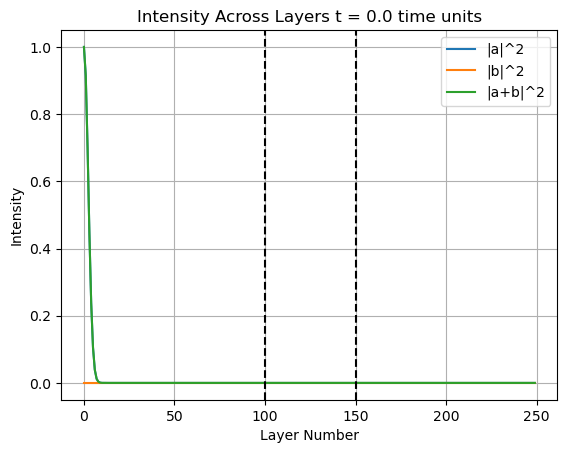

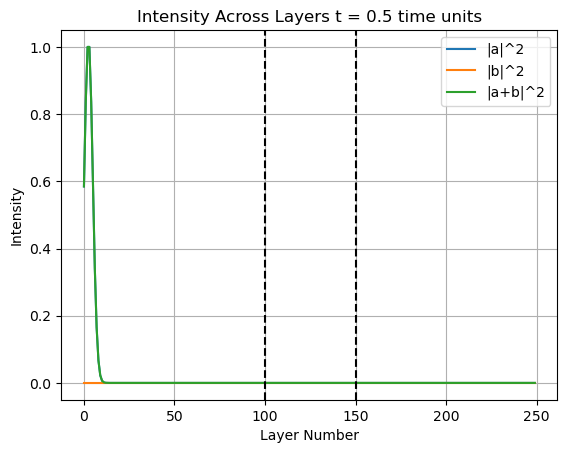

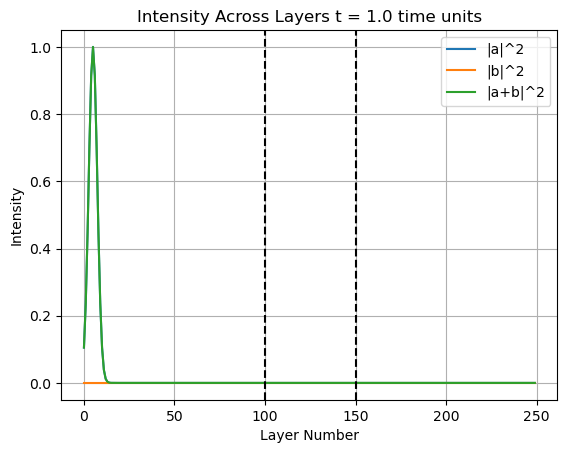

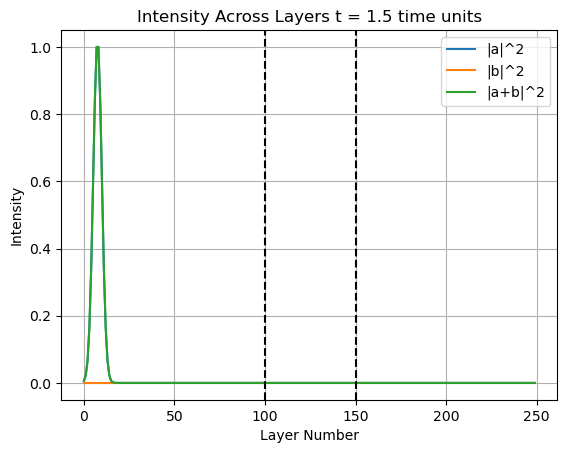

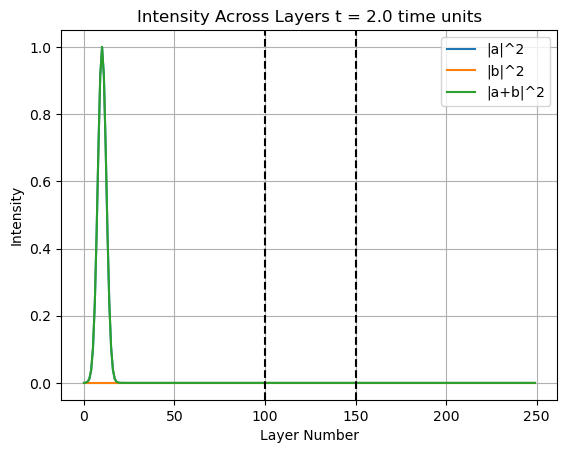

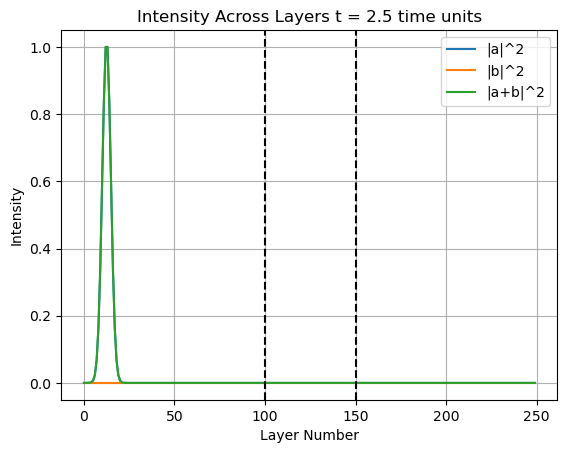

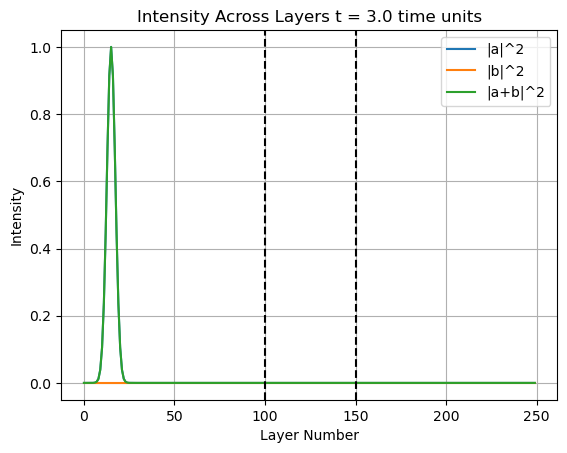

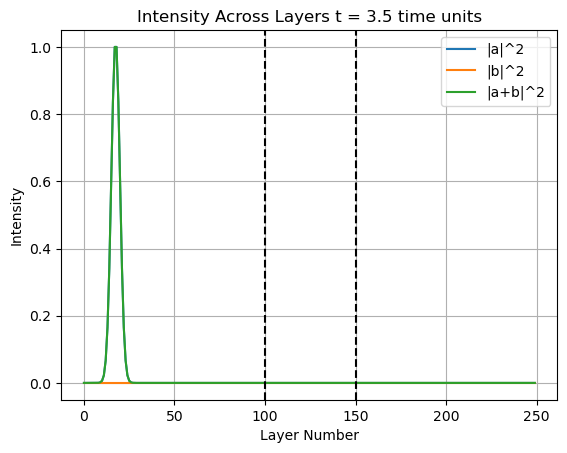

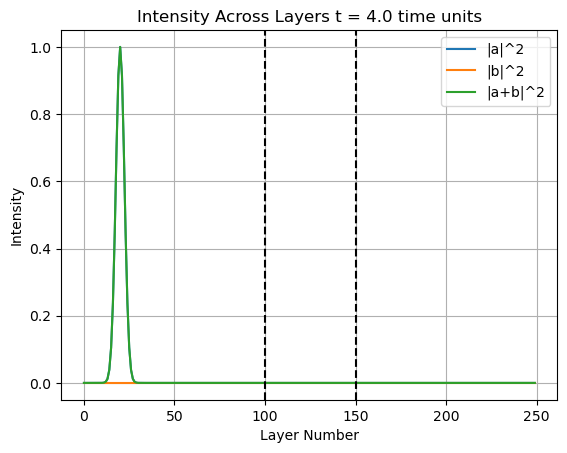

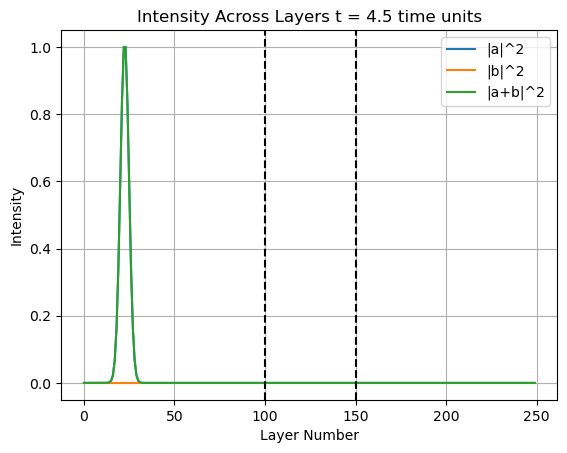

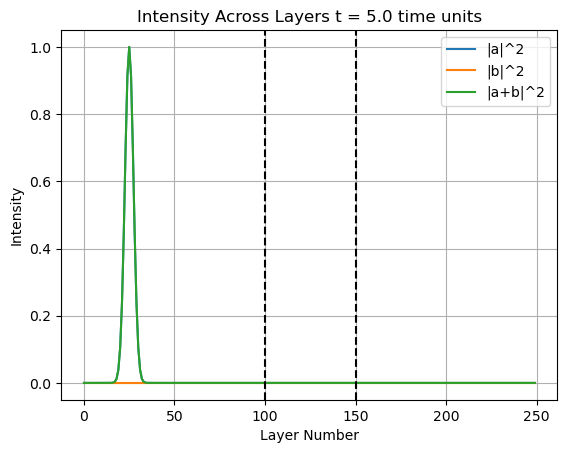

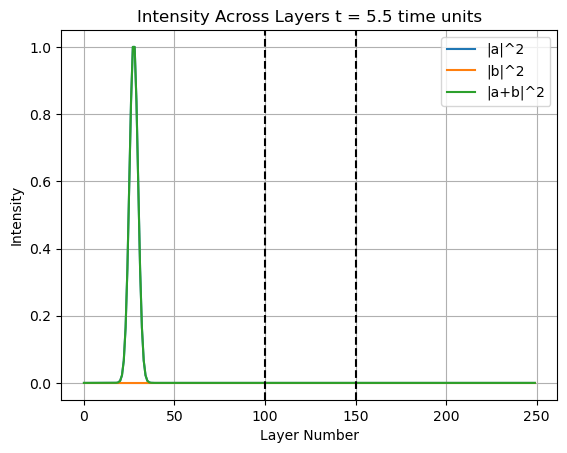

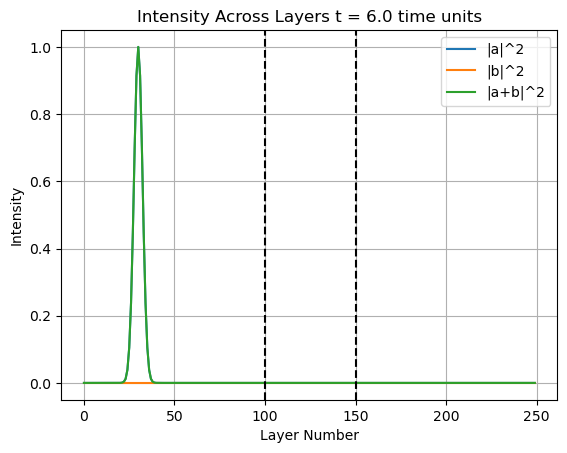

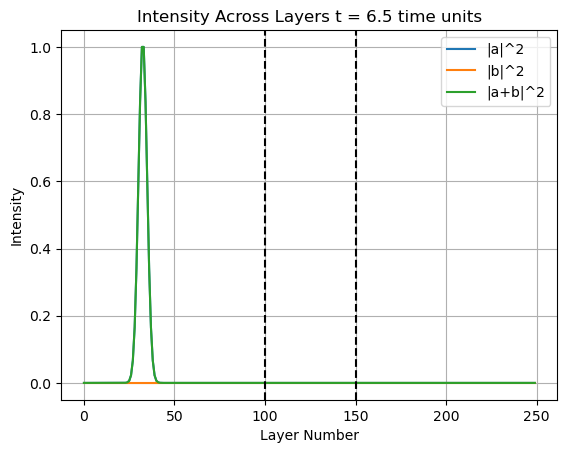

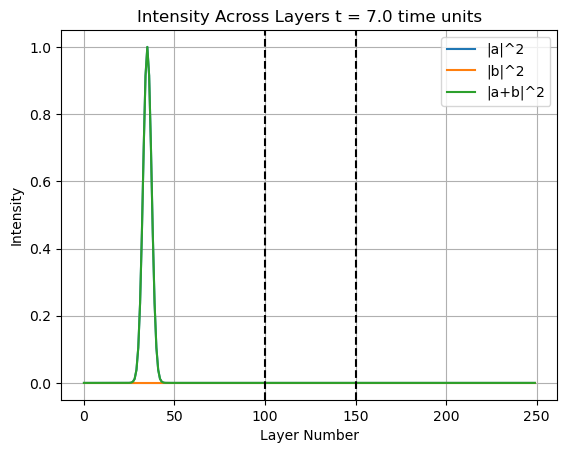

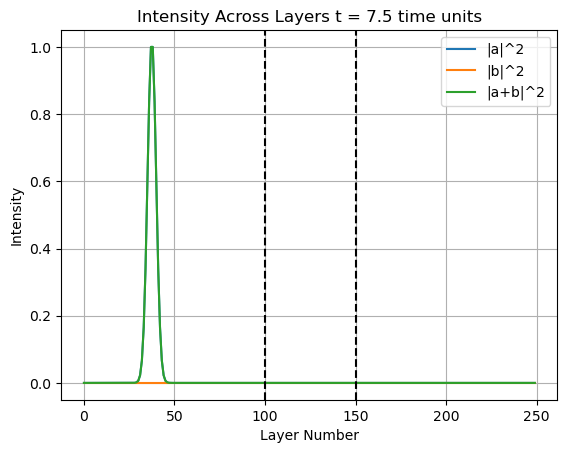

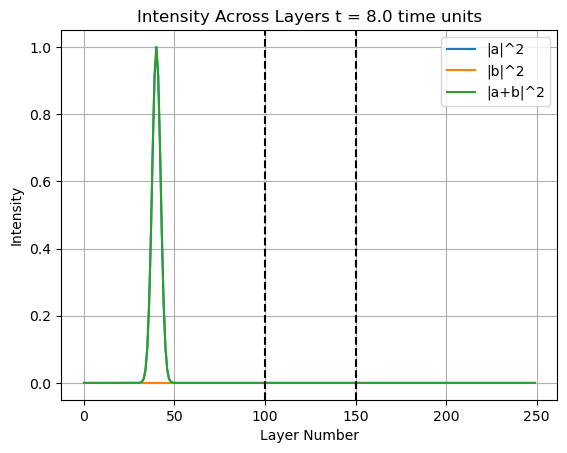

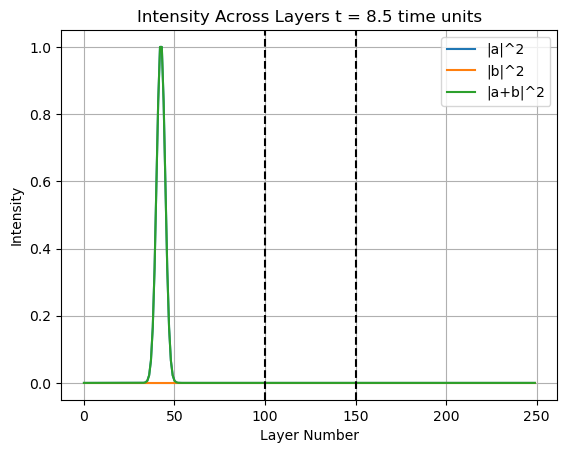

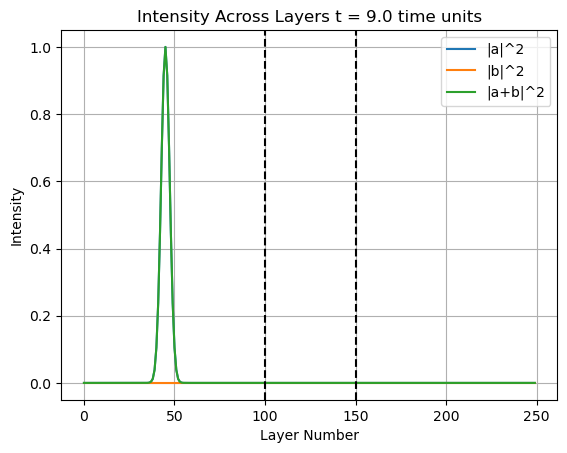

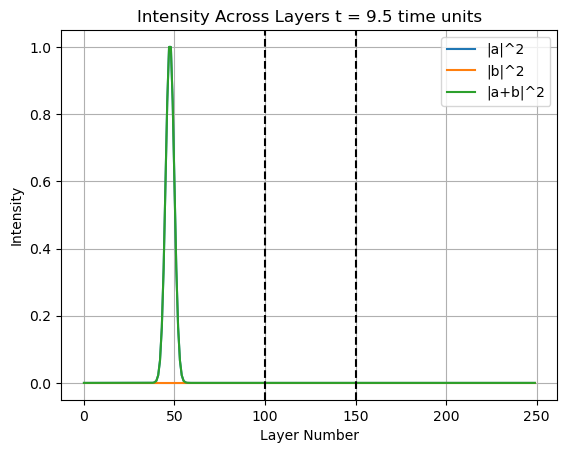

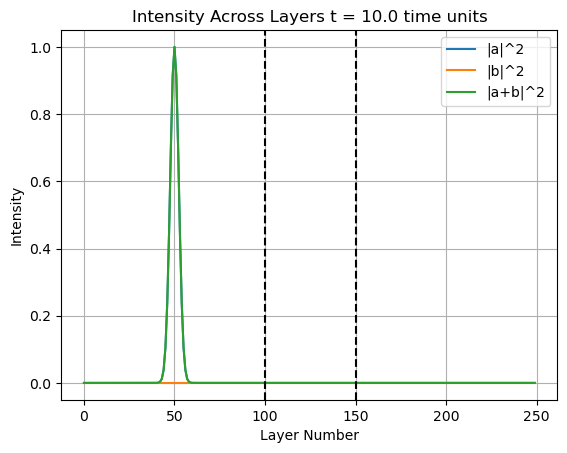

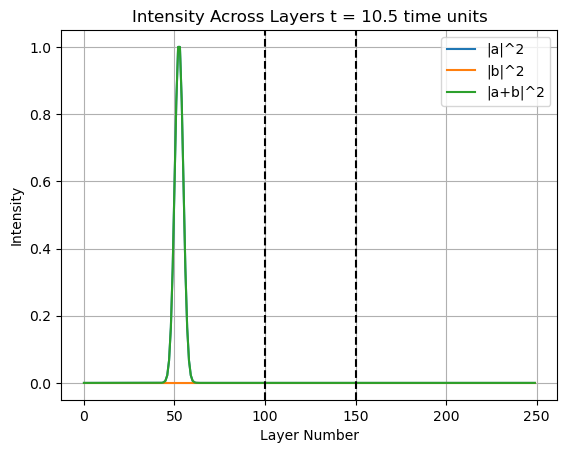

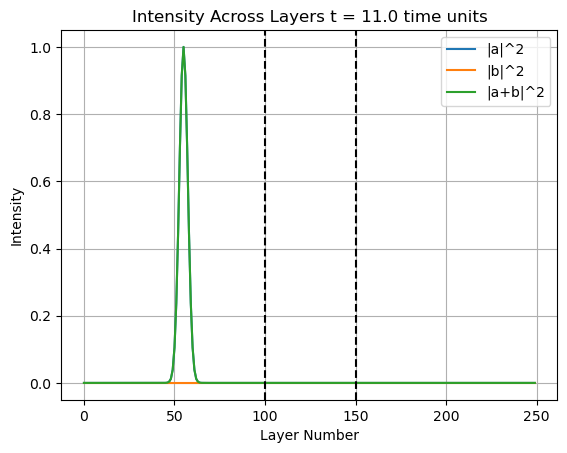

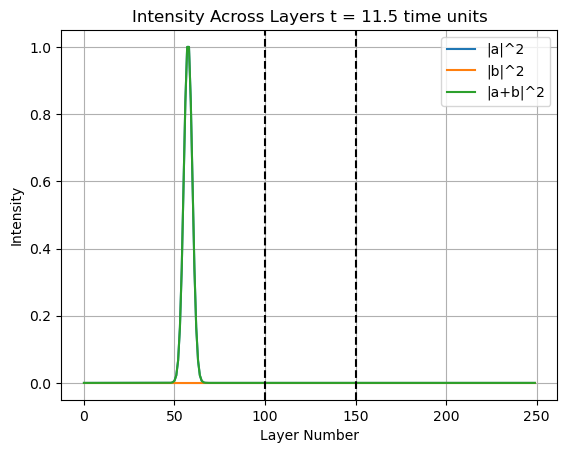

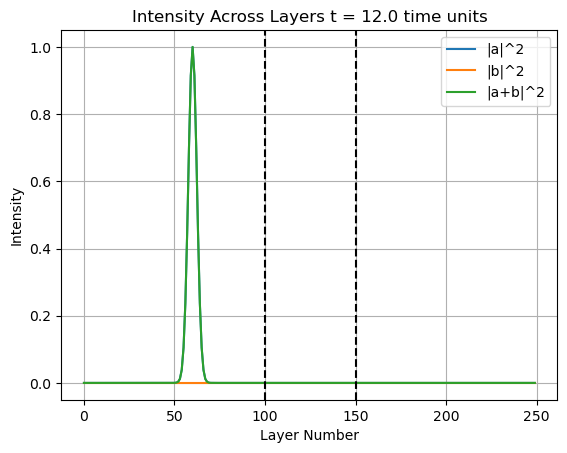

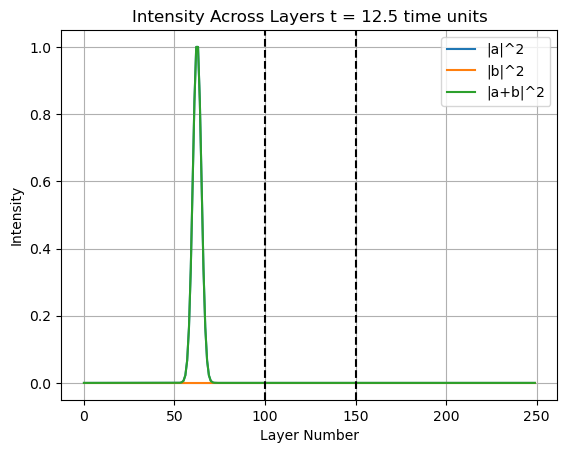

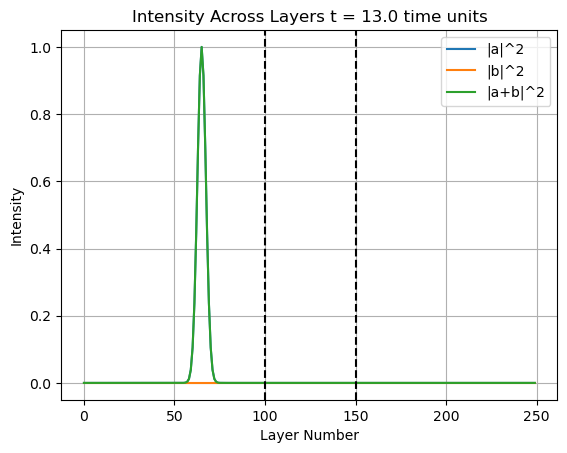

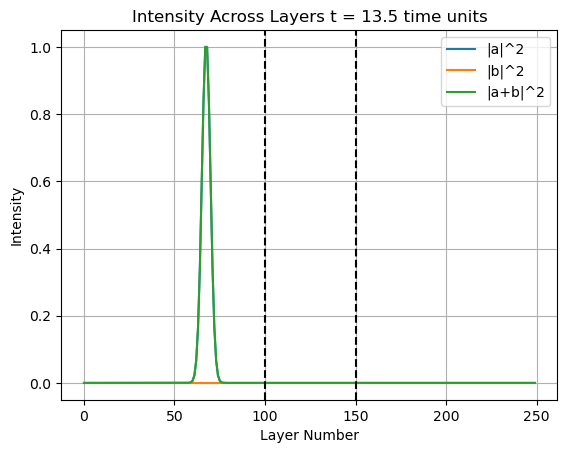

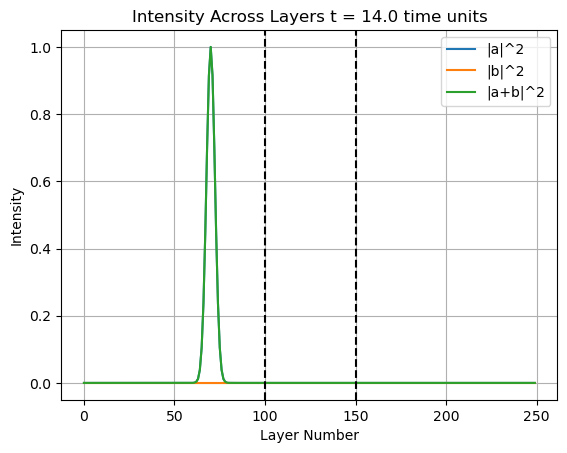

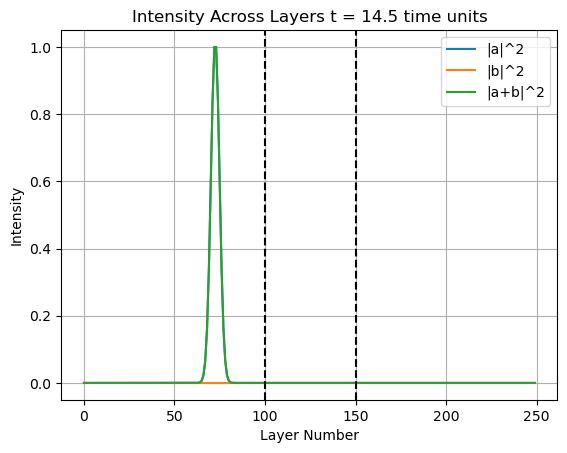

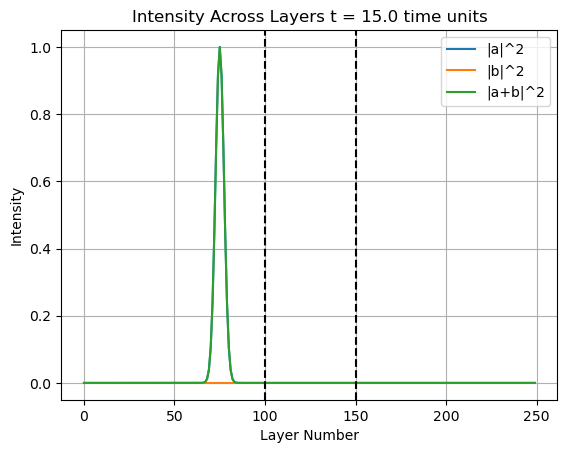

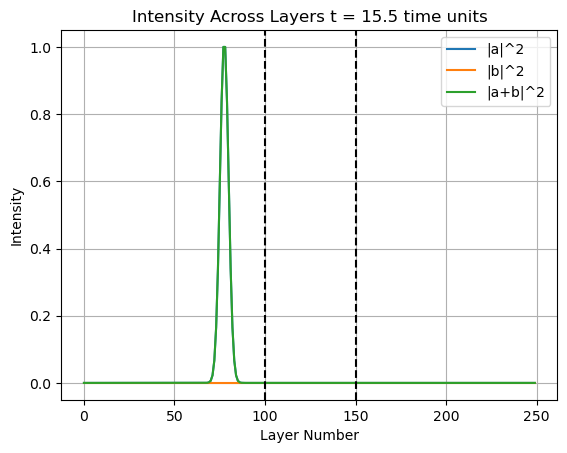

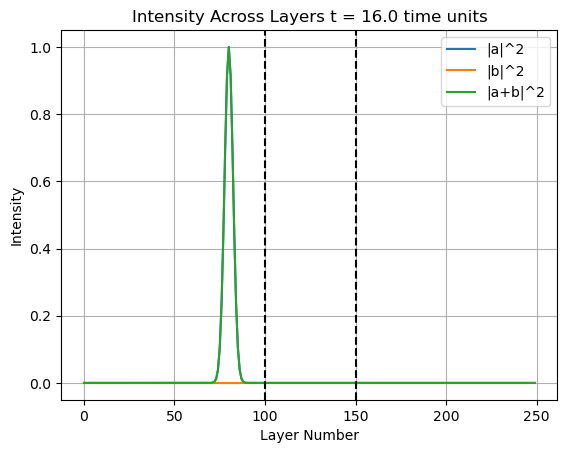

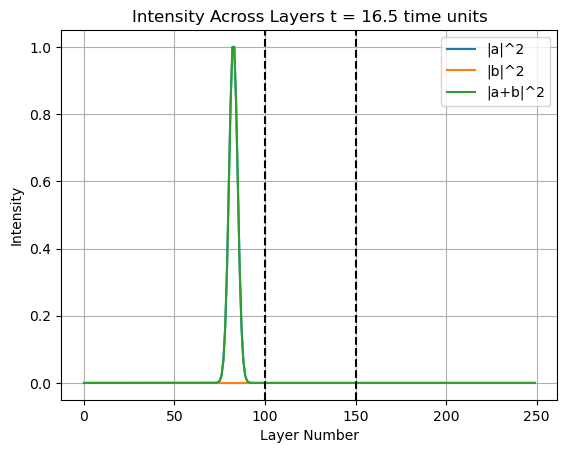

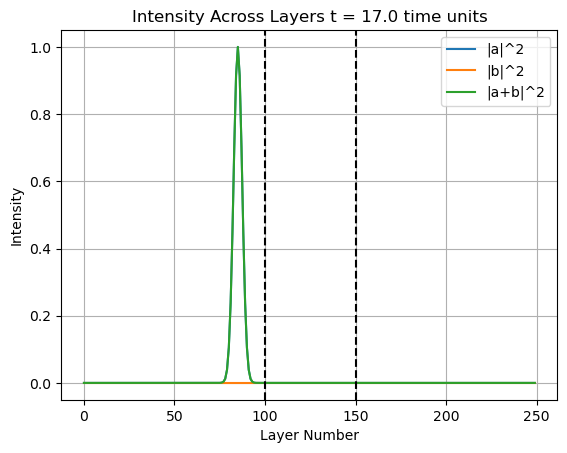

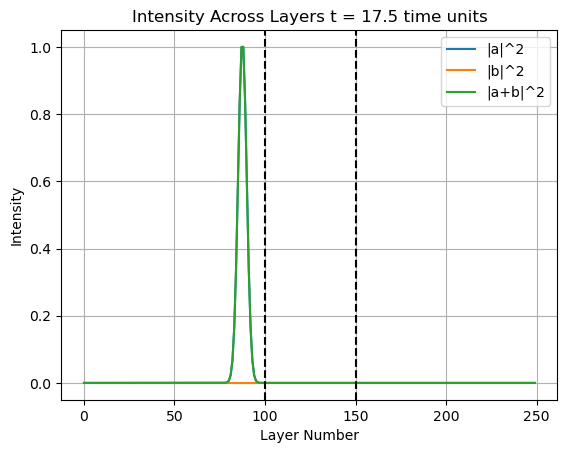

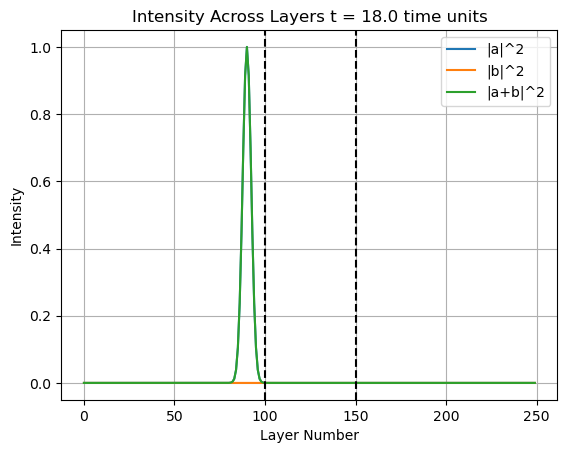

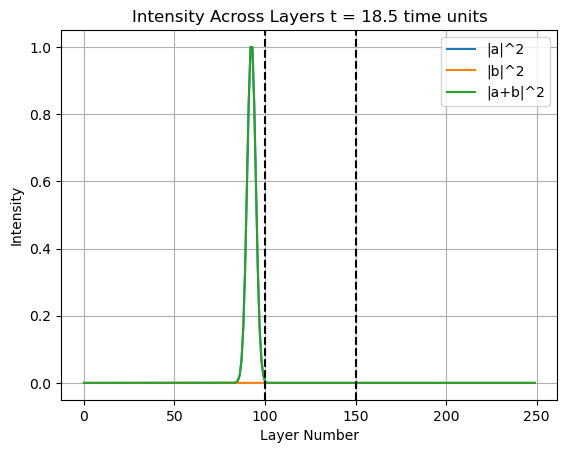

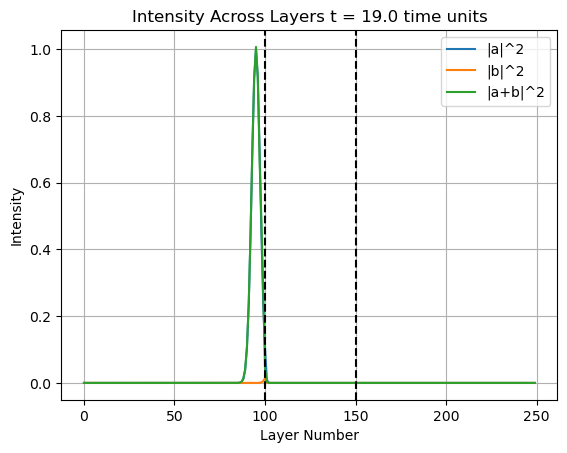

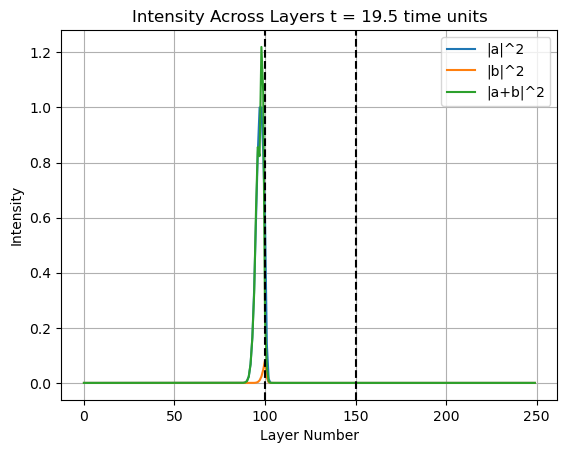

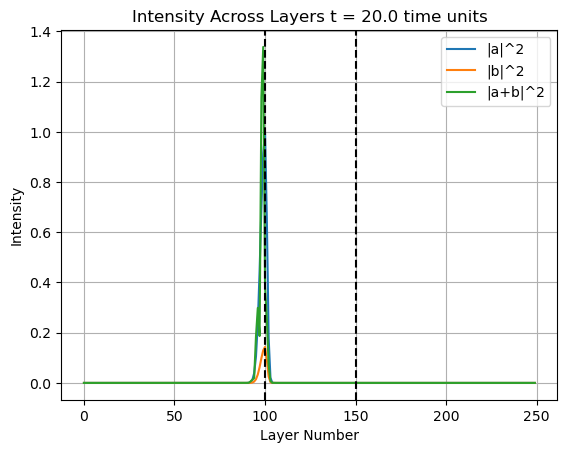

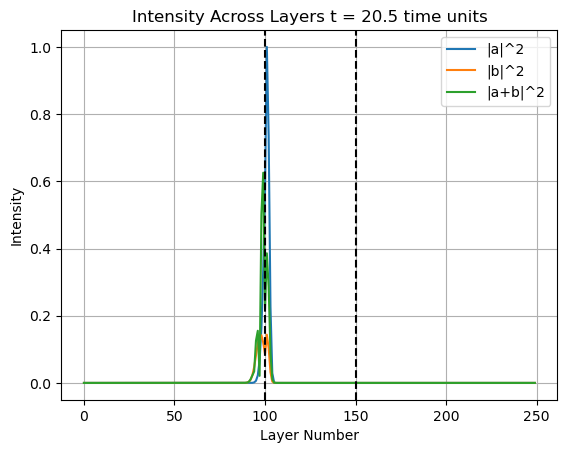

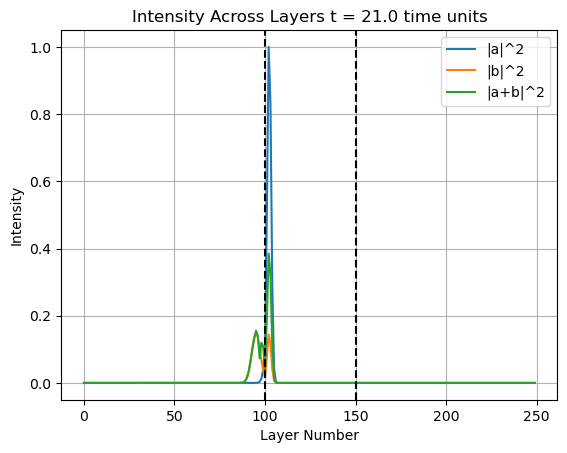

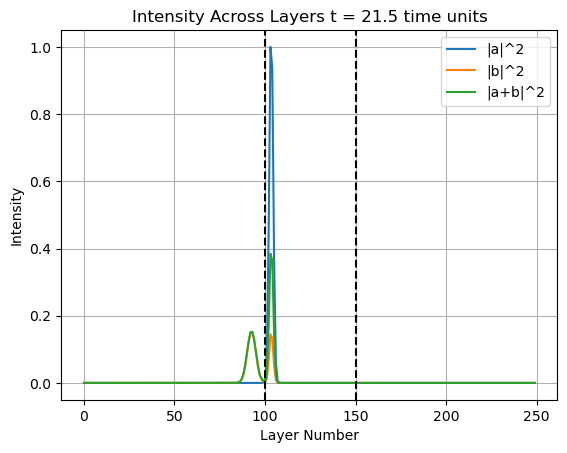

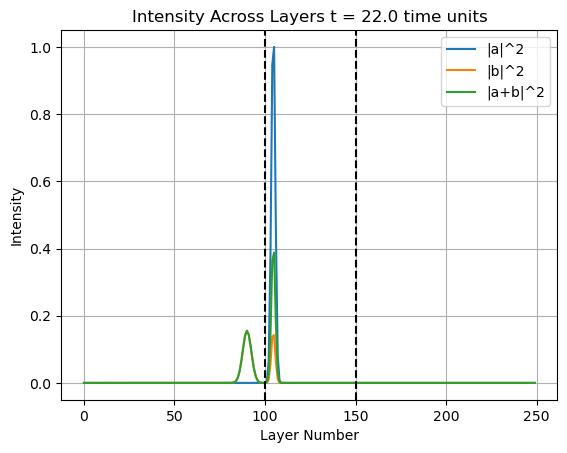

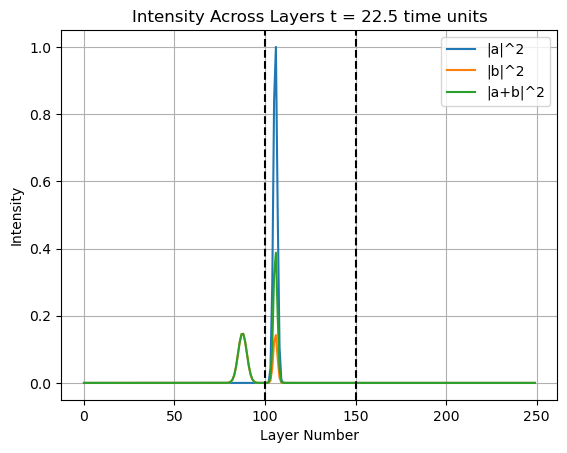

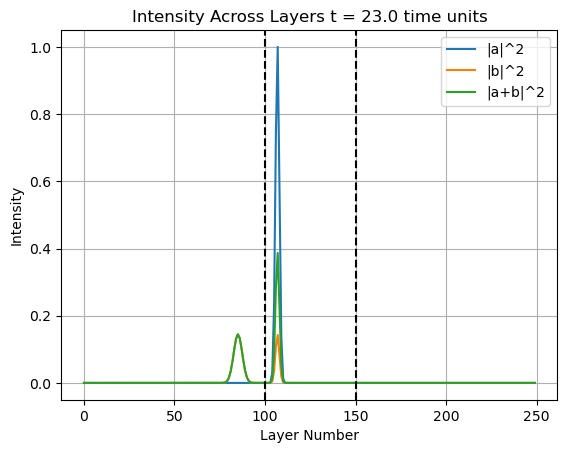

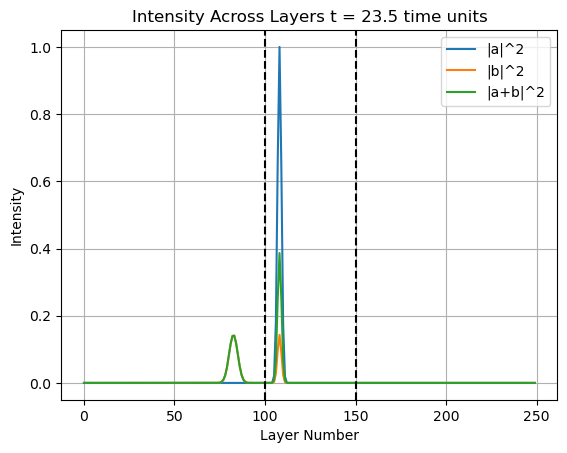

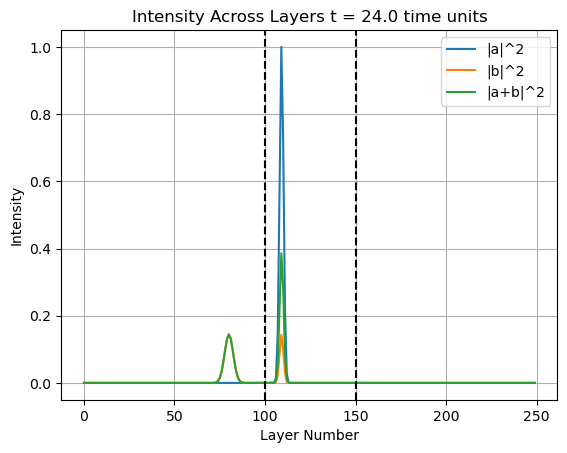

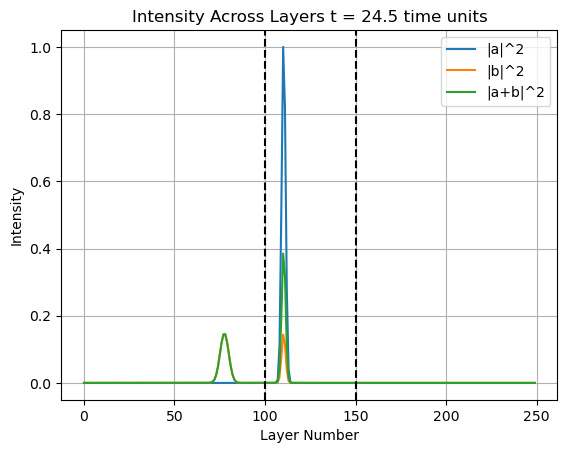

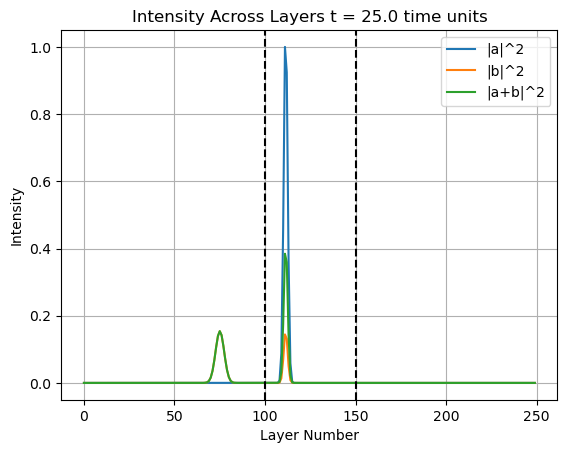

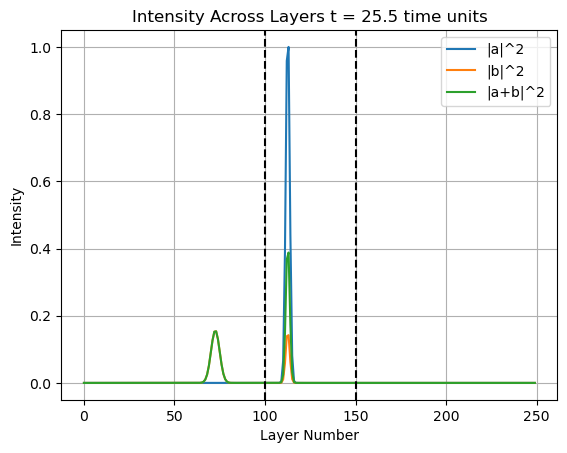

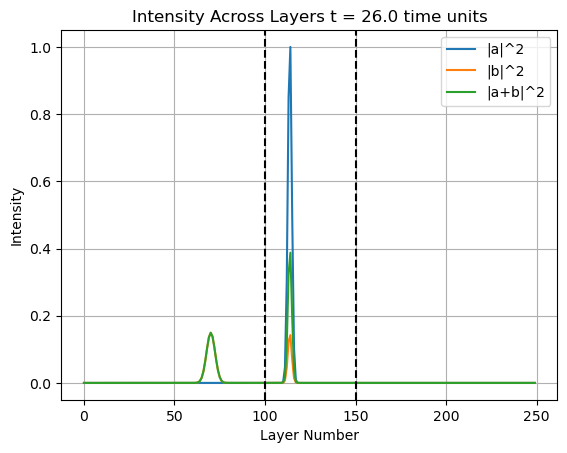

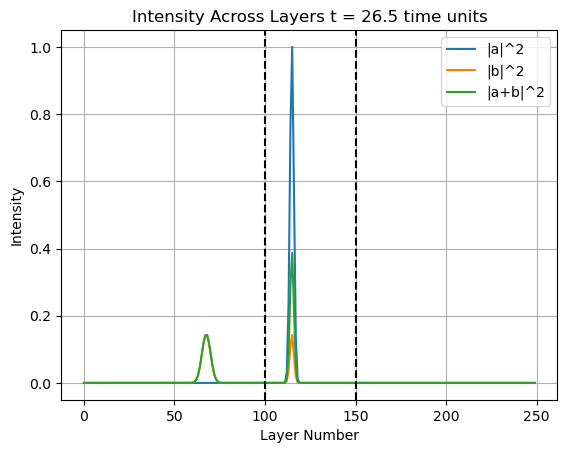

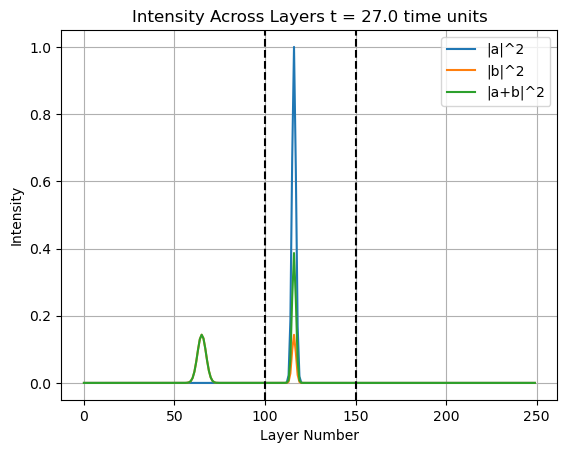

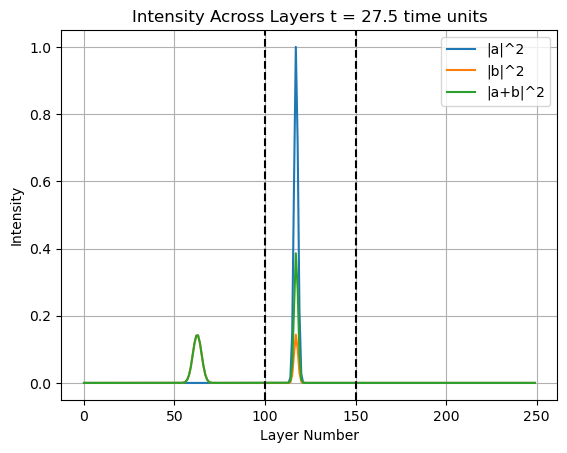

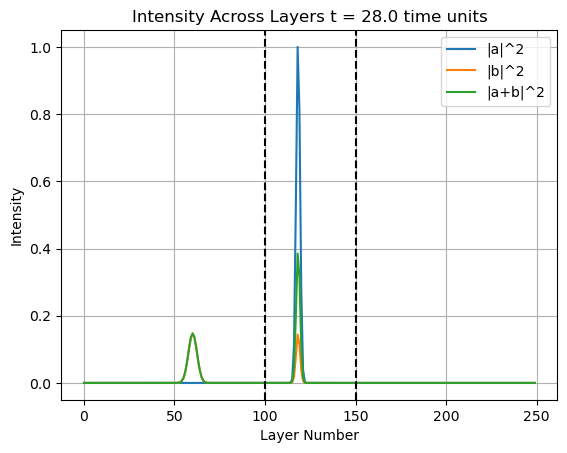

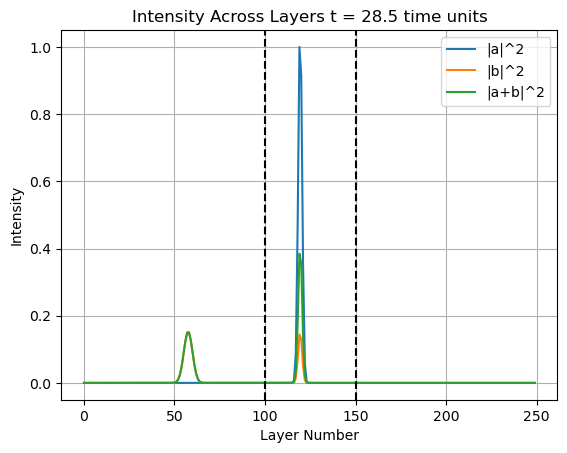

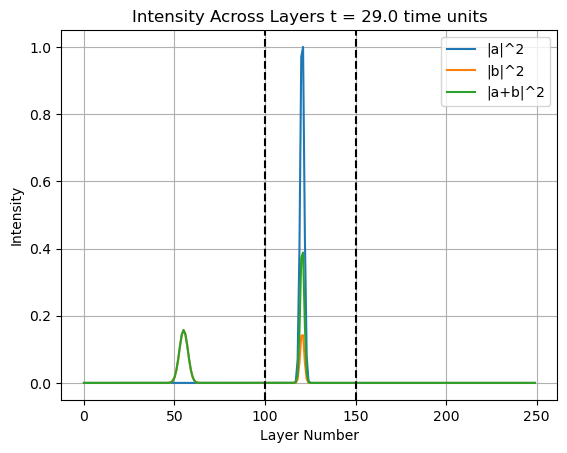

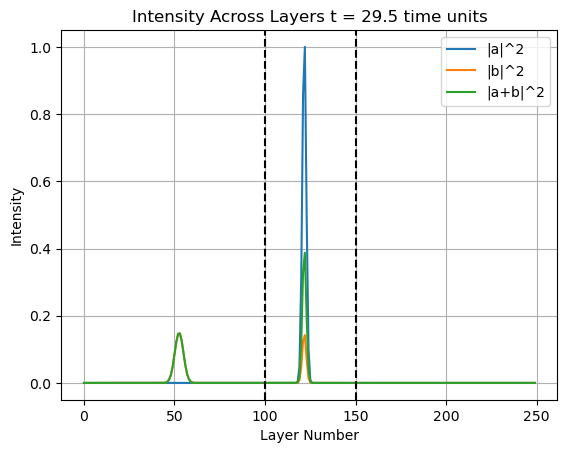

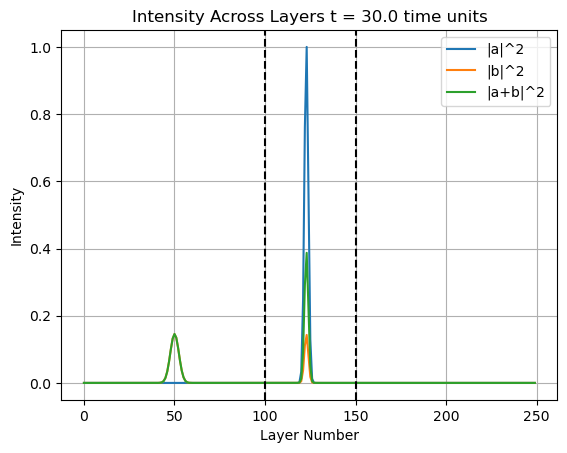

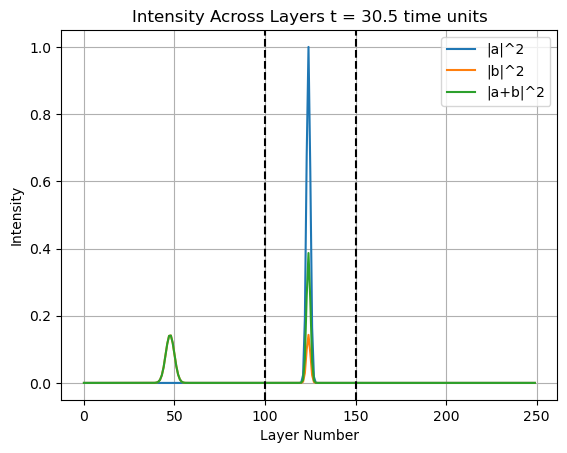

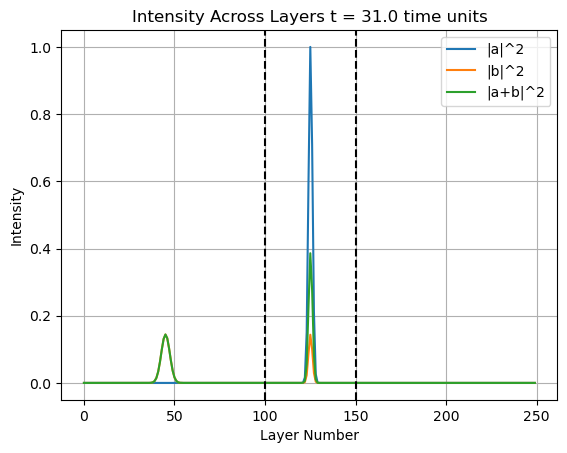

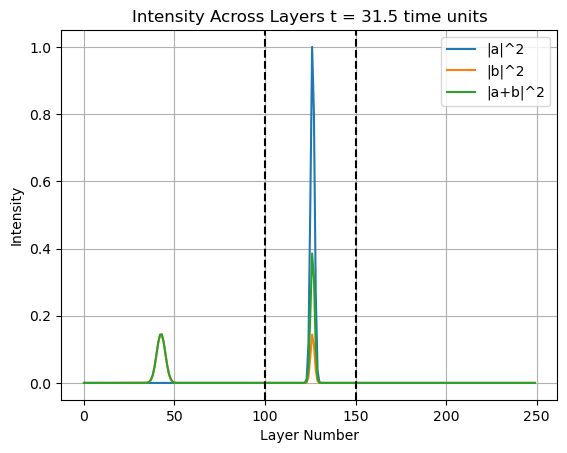

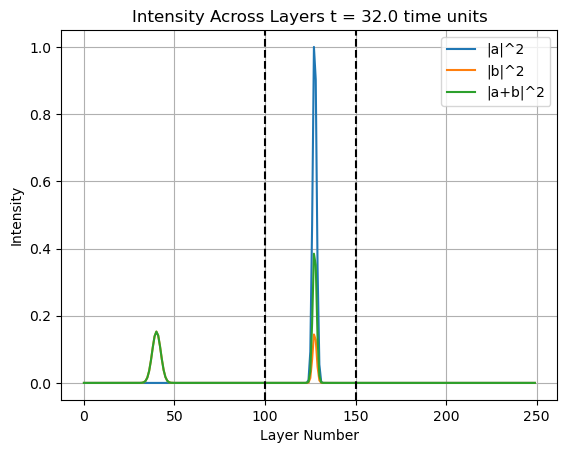

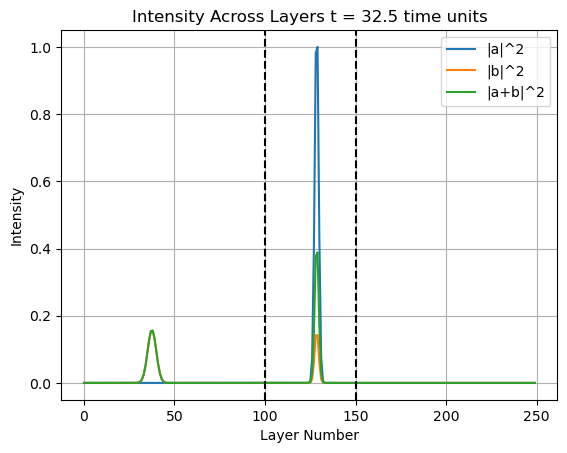

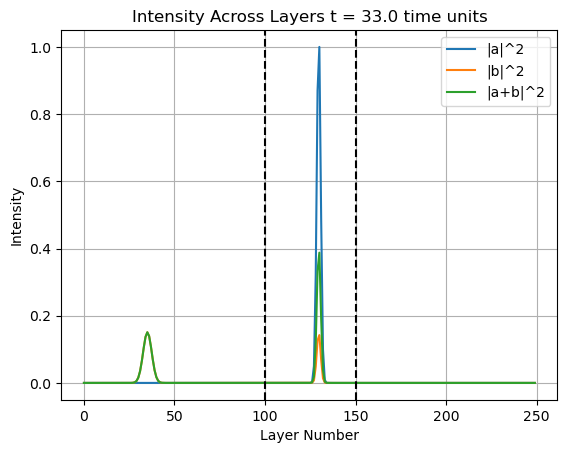

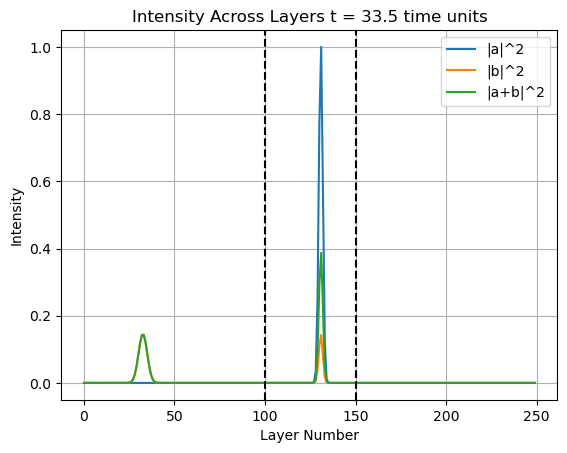

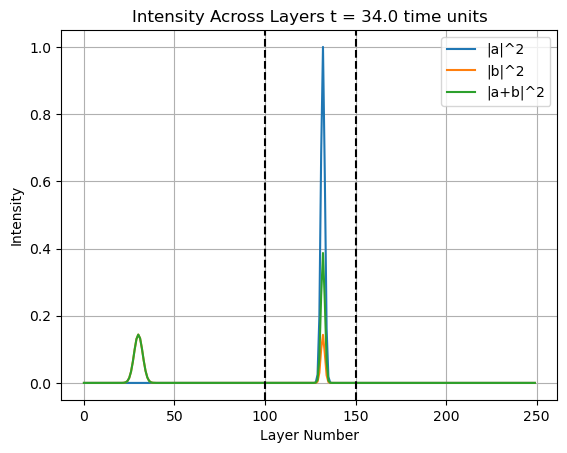

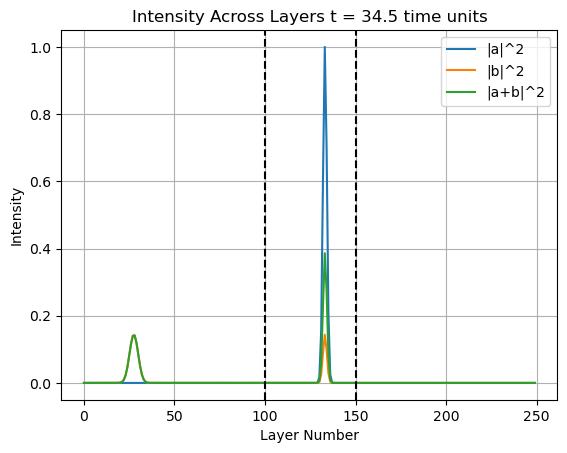

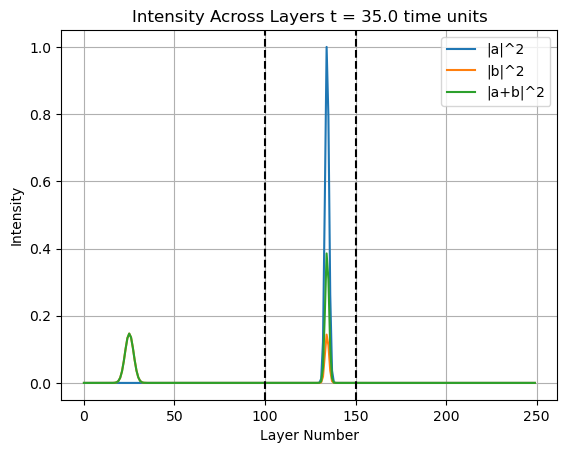

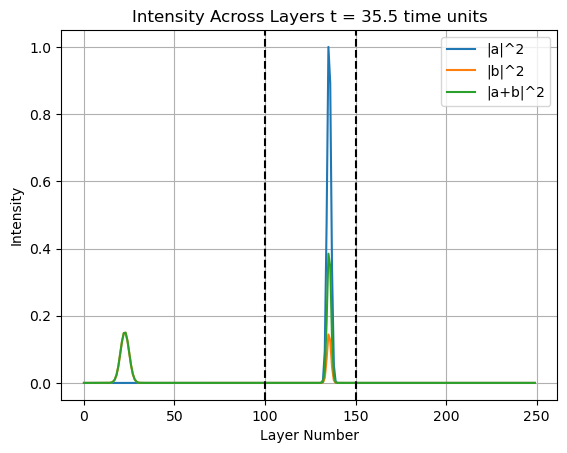

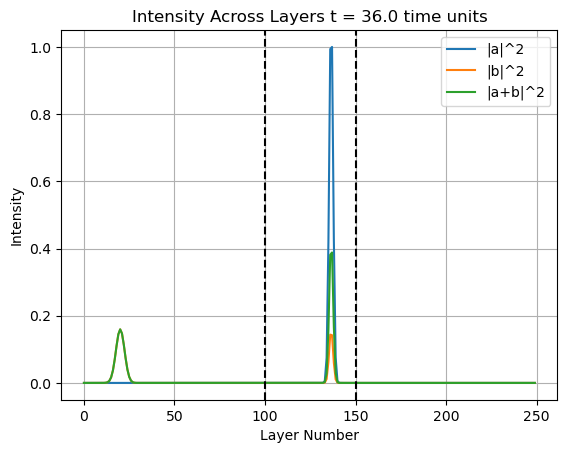

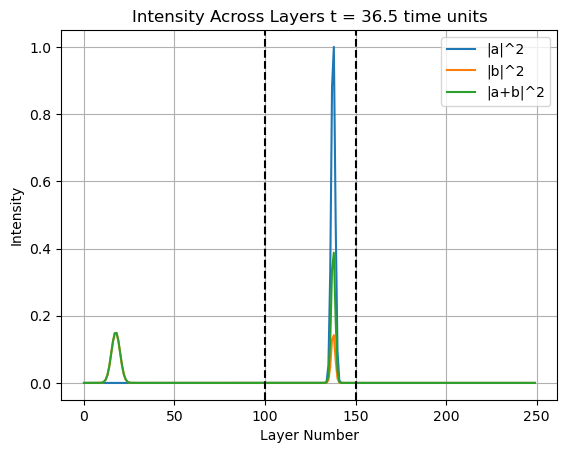

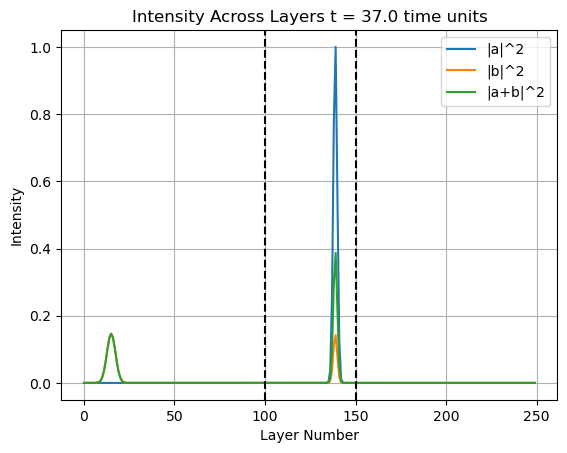

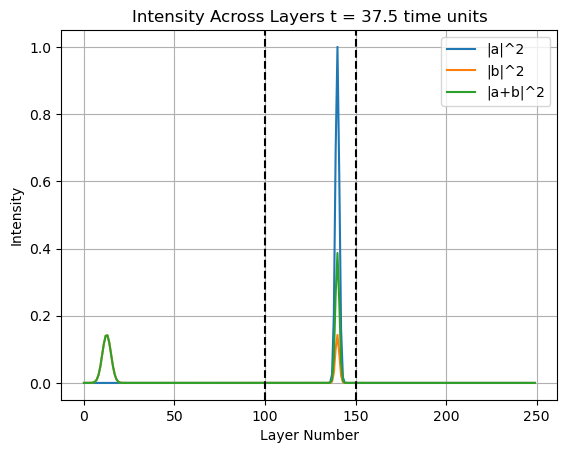

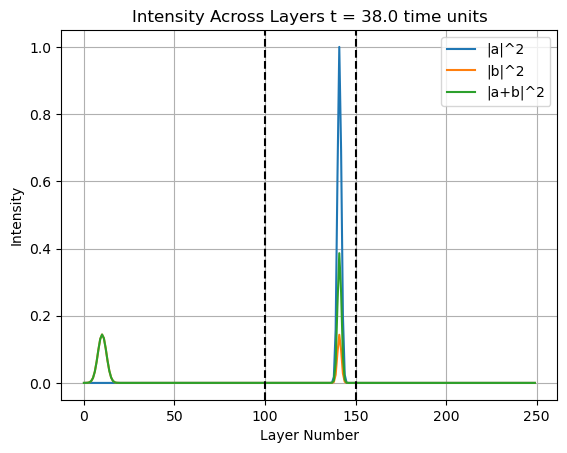

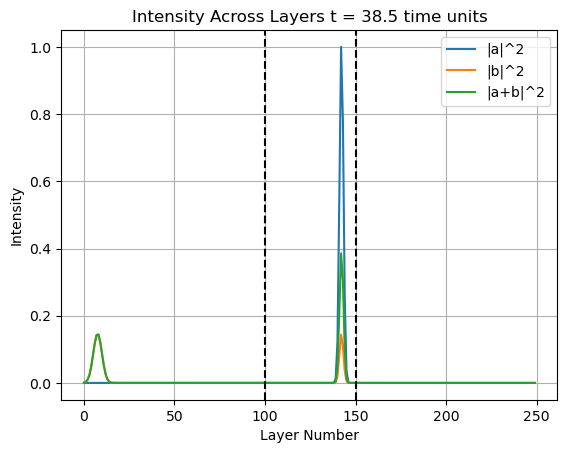

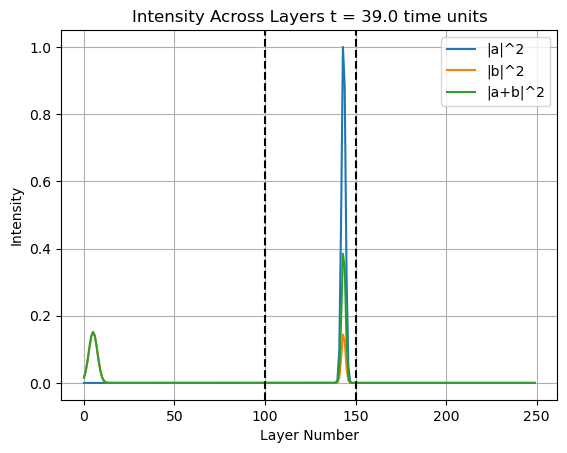

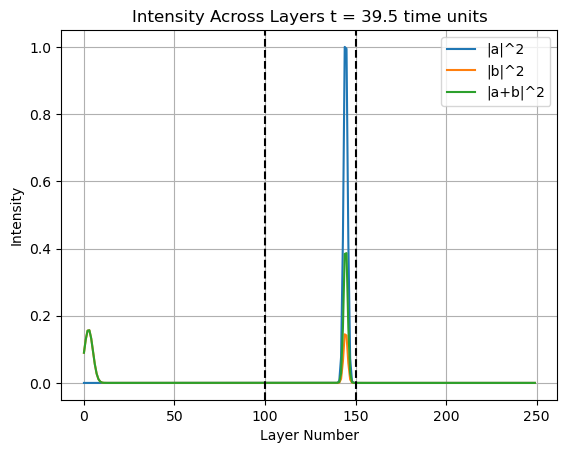

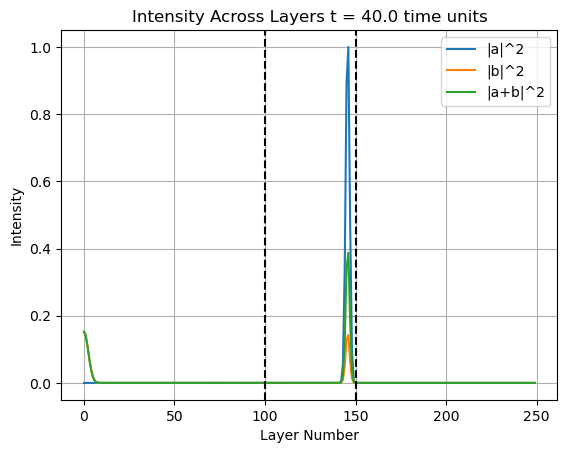

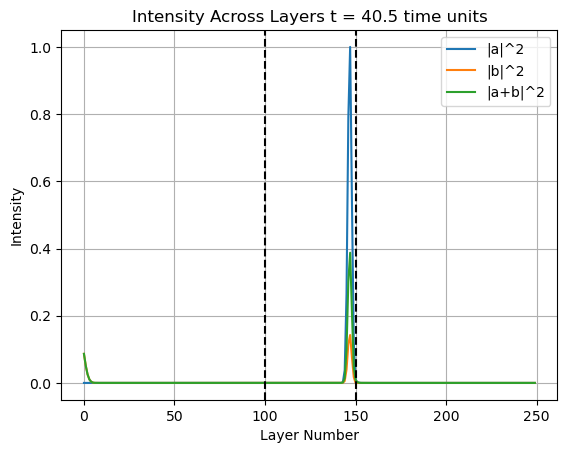

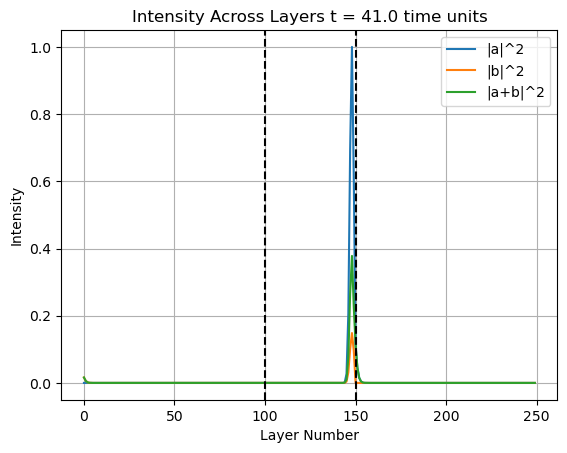

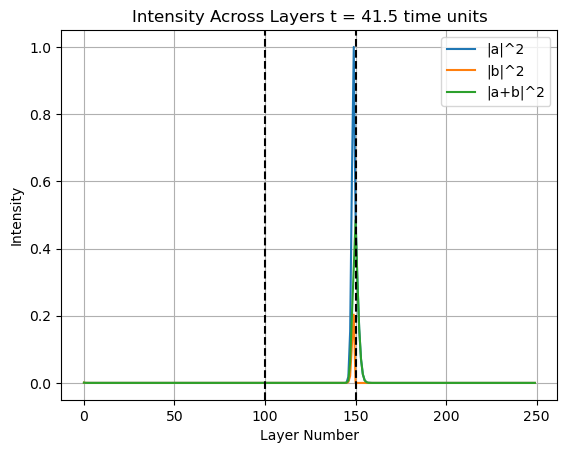

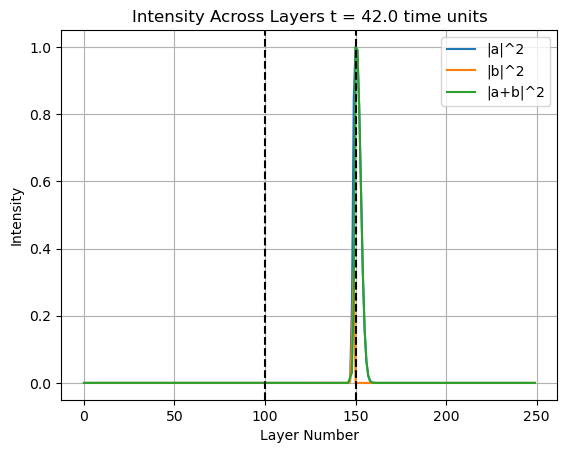

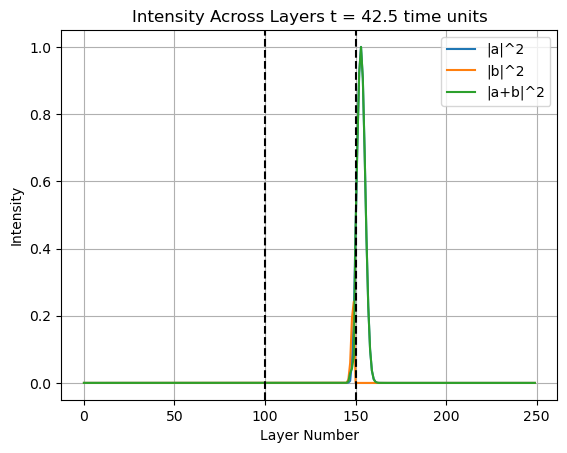

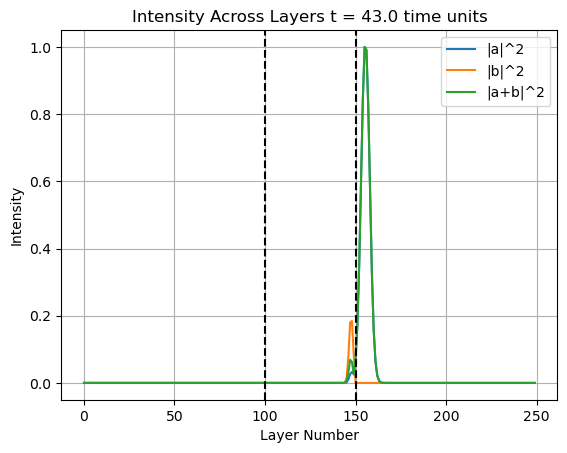

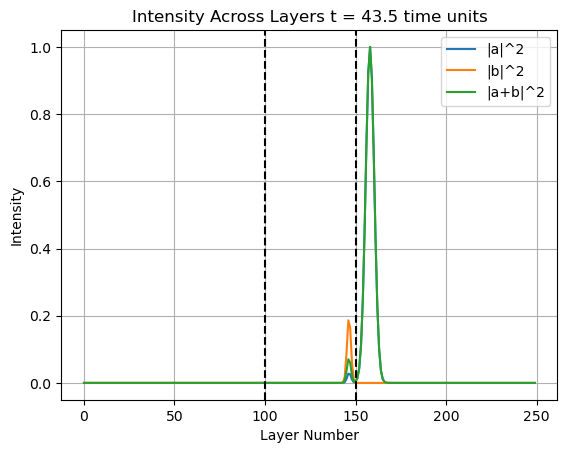

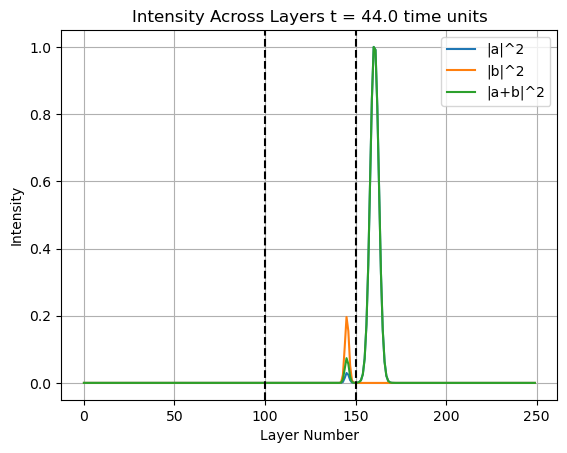

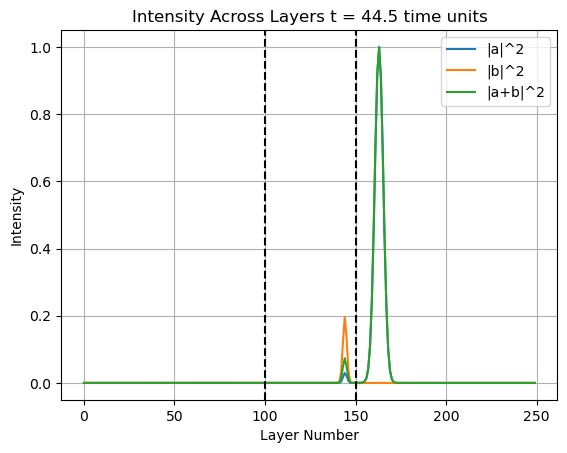

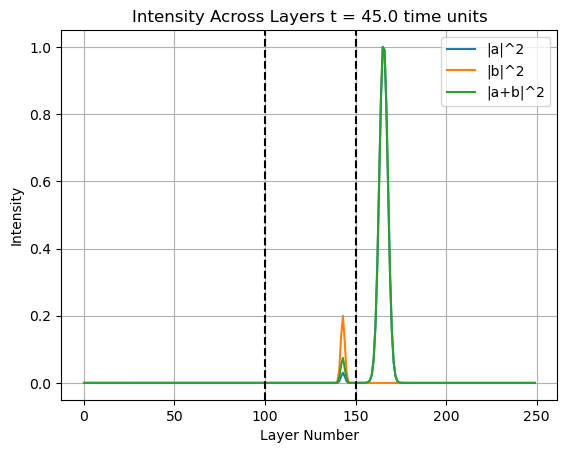

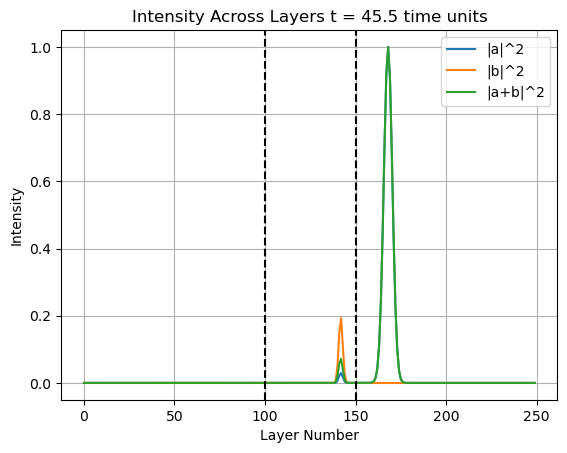

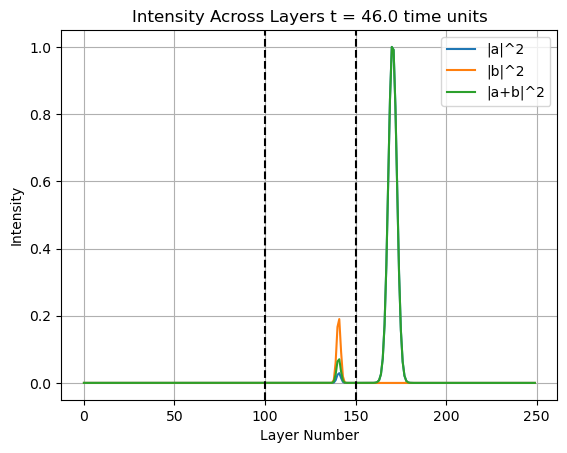

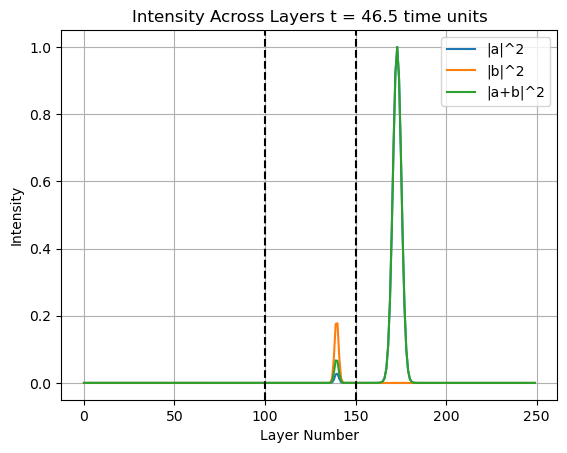

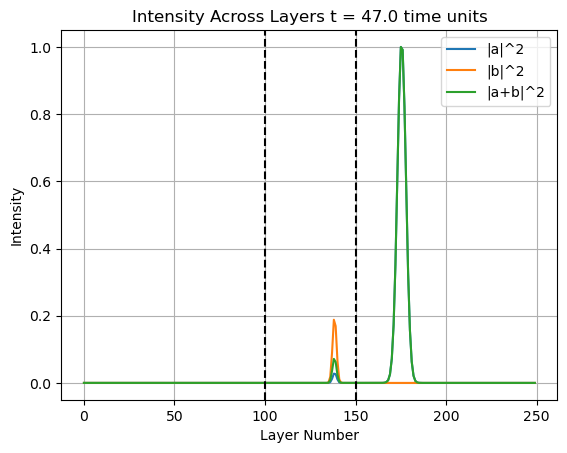

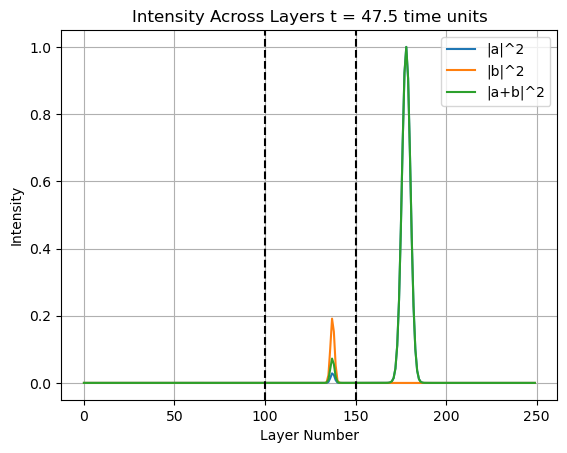

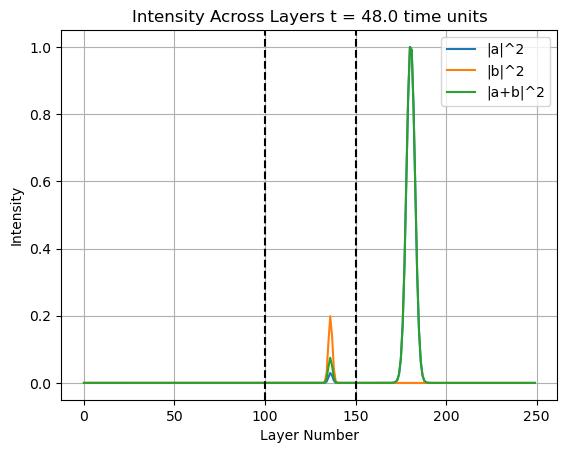

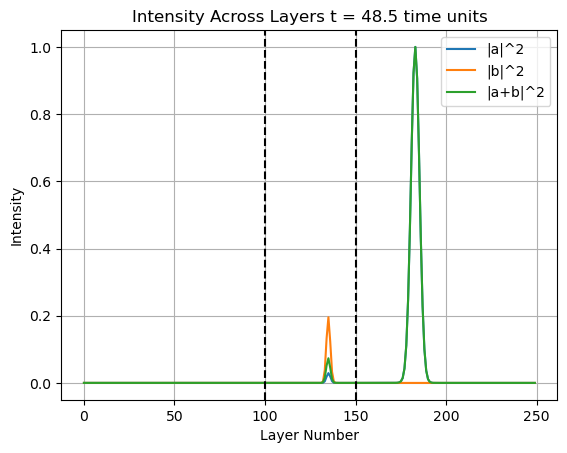

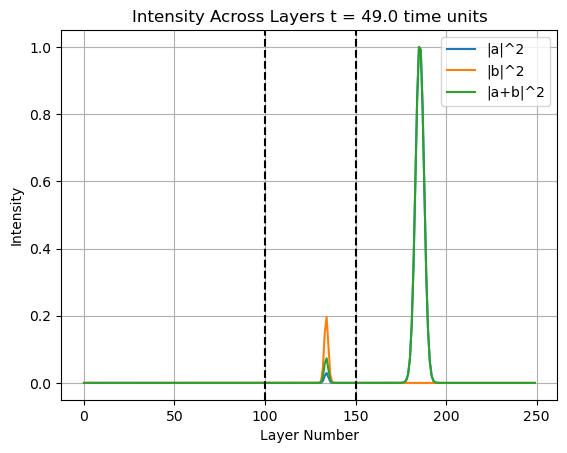

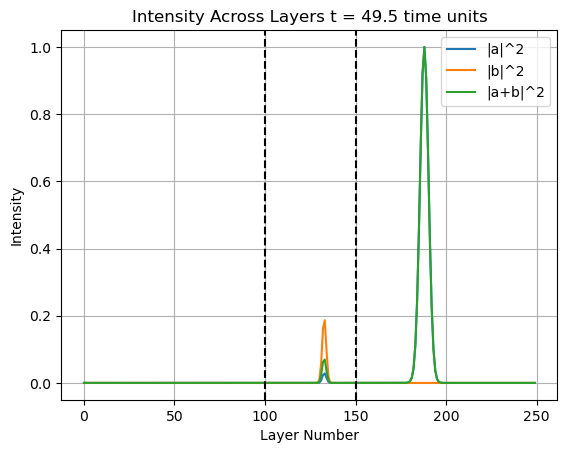

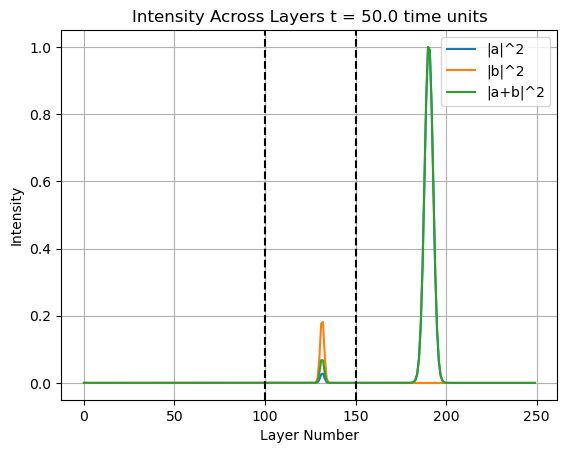

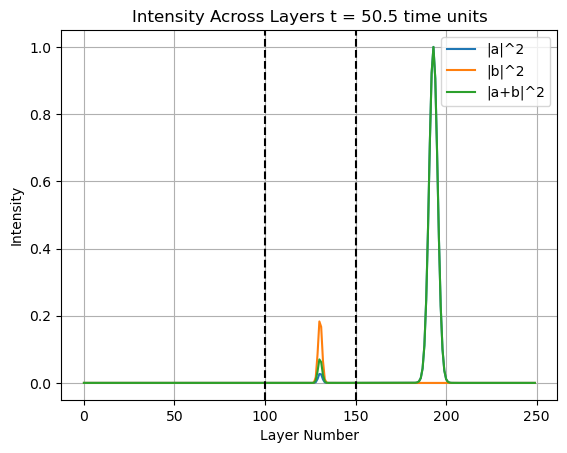

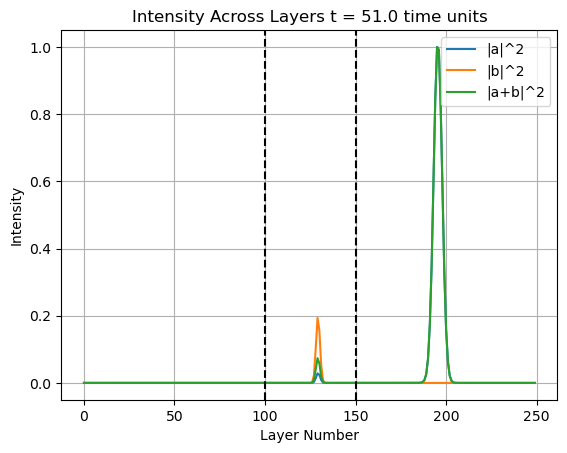

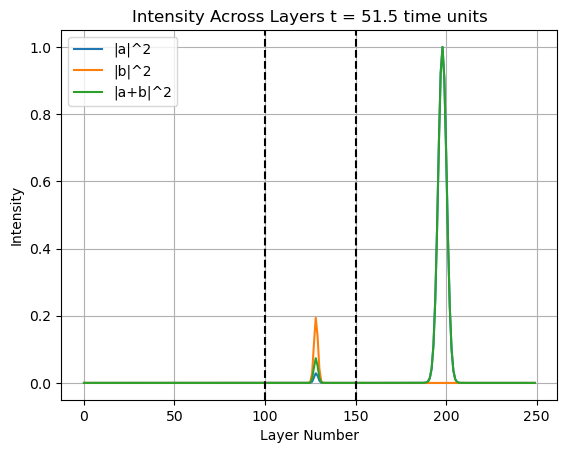

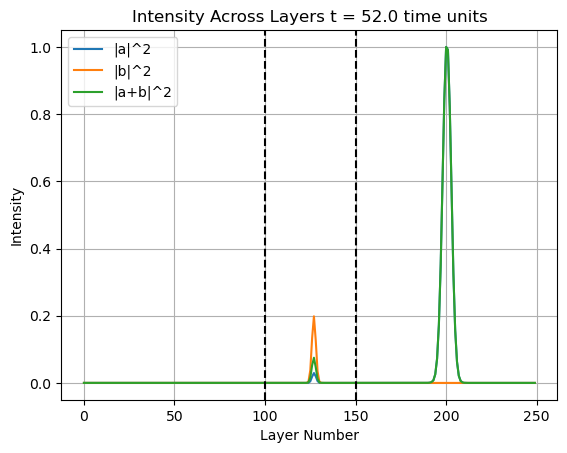

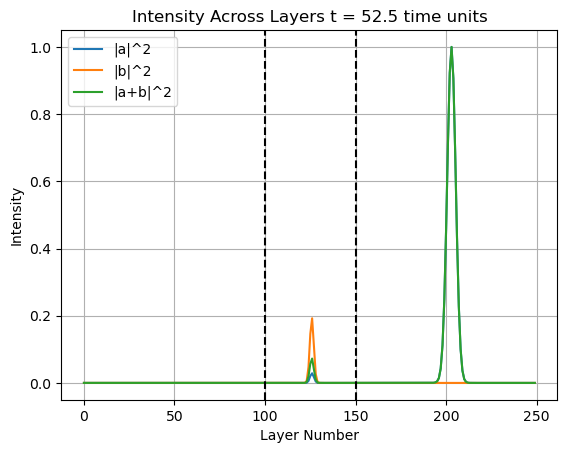

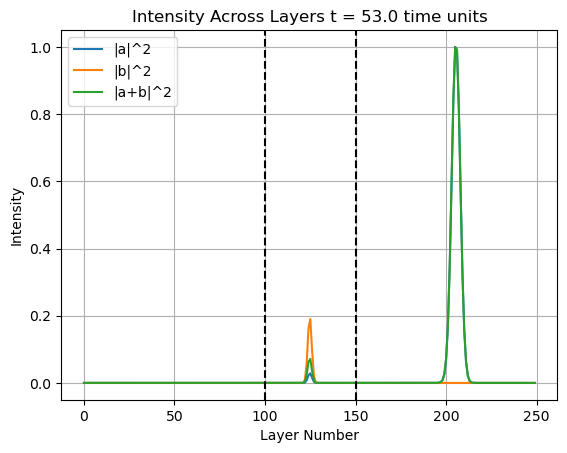

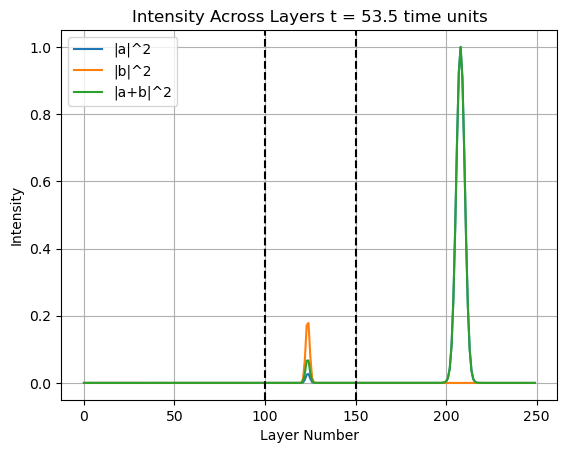

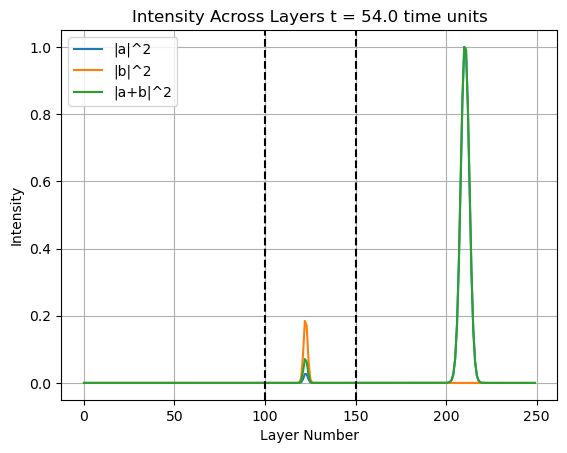

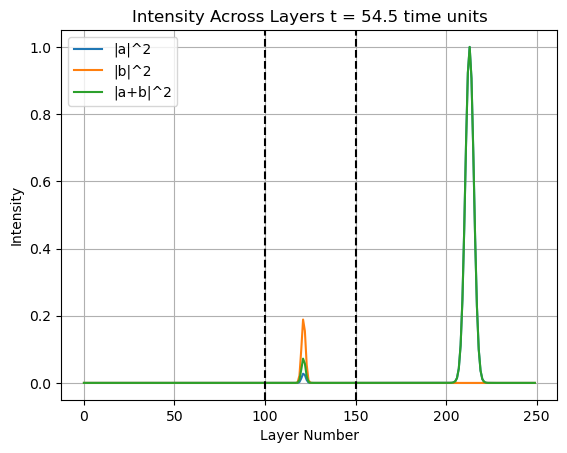

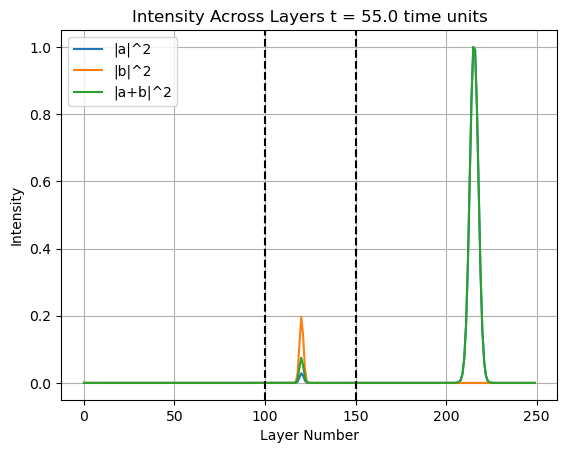

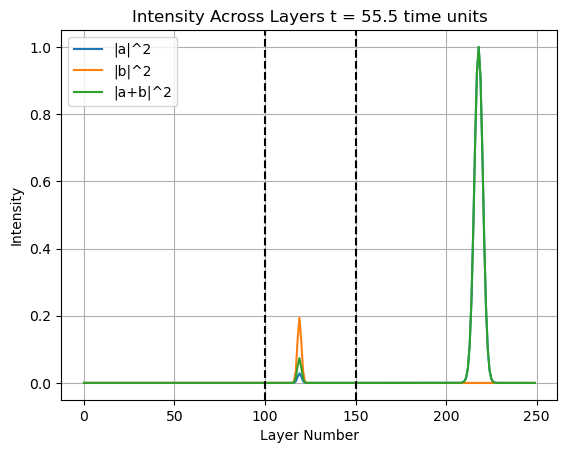

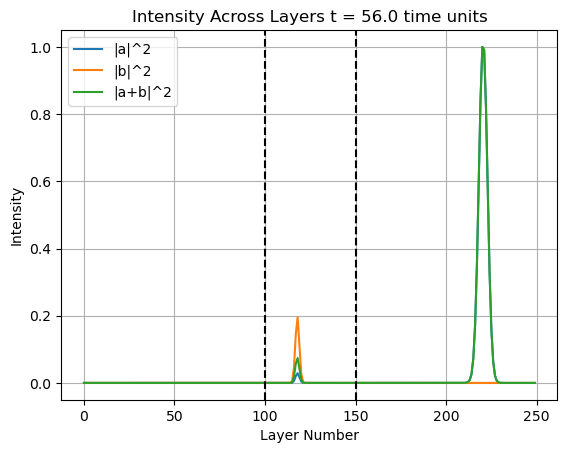

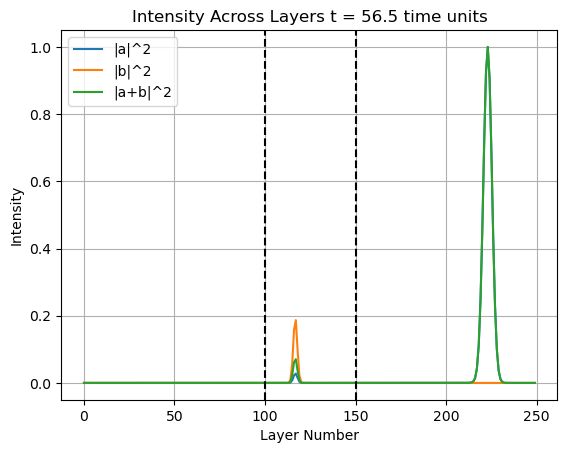

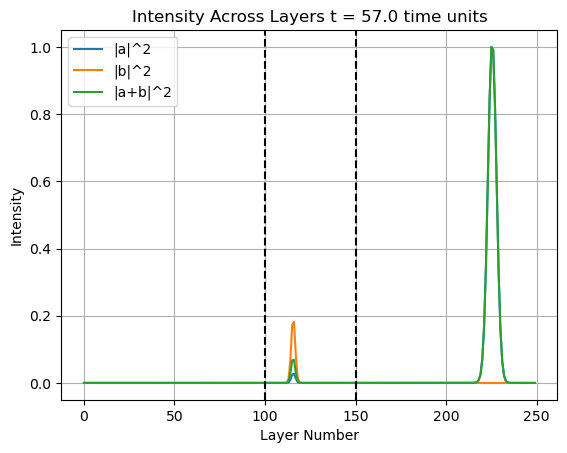

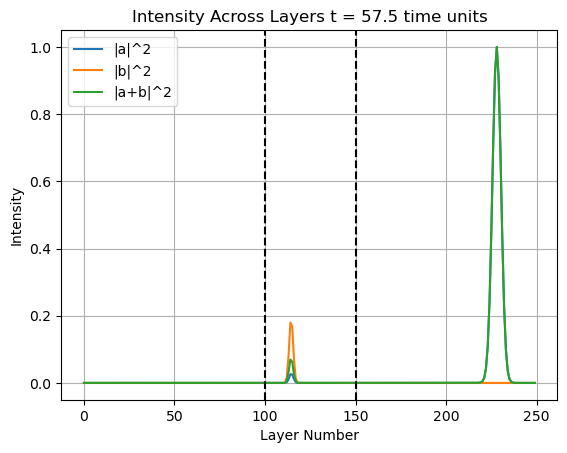

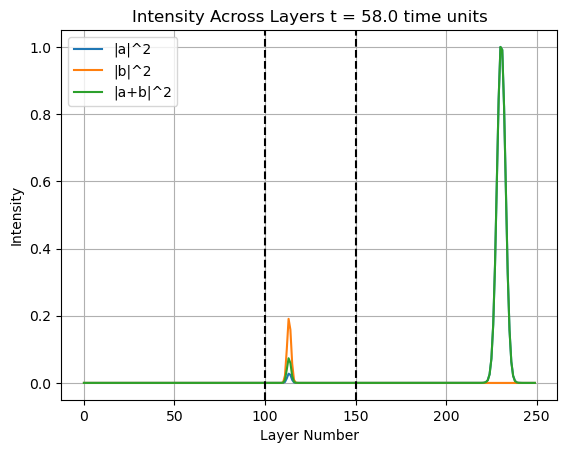

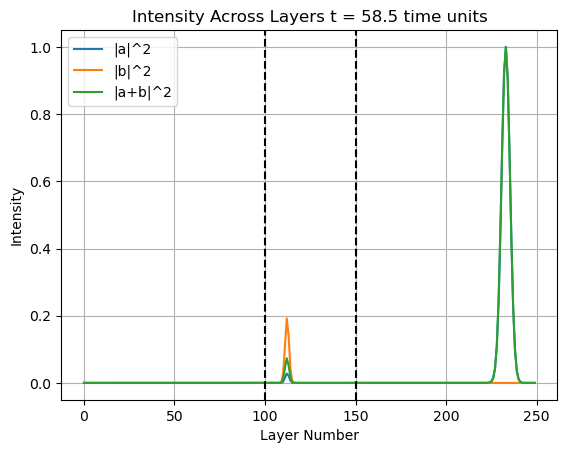

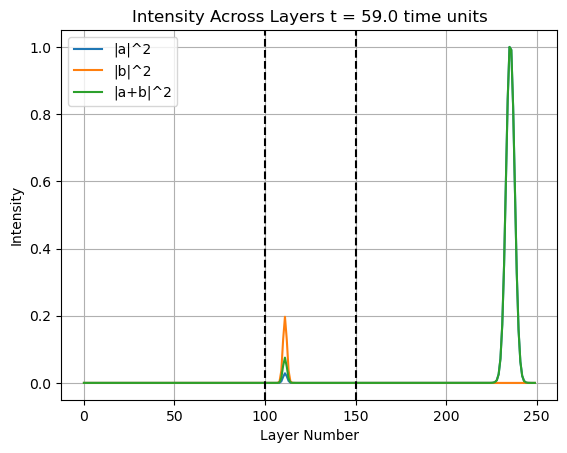

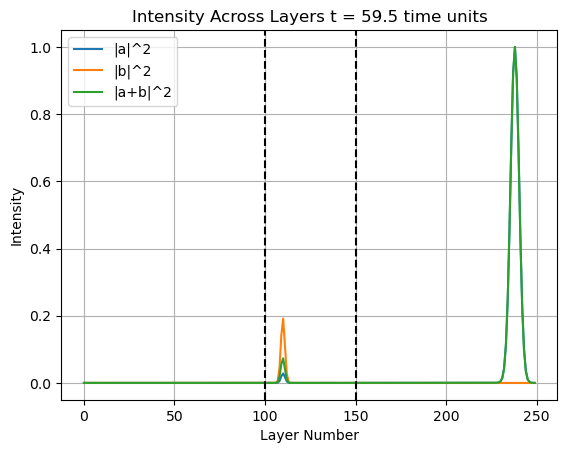

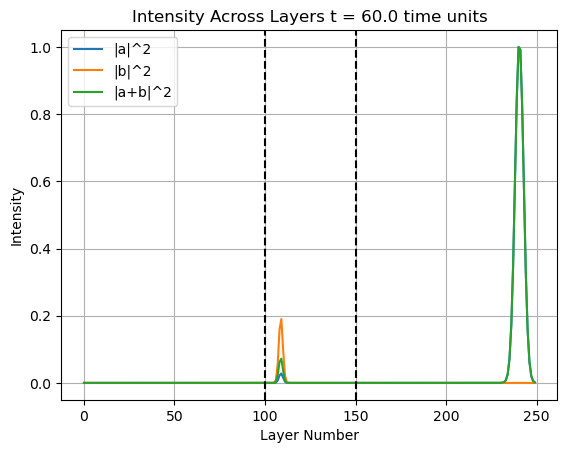

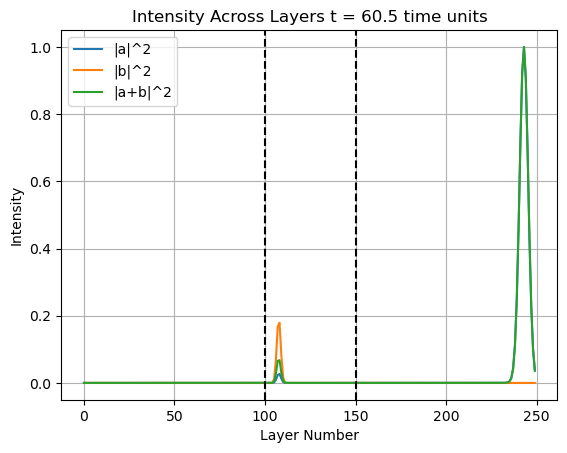

In [ ]:
for t in range(len(t_vals)):
    plot_amps(a_norm[t],b_norm[t],t_vals[t],np.array(nums1))

## Momentum

In [ ]:
ai_3d_multi_tk = sto3d_multi_tk(ai_pol_tk)
bi_3d_multi_tk = sto3d_multi_tk(bi_pol_tk)
Hai_3d_multi_tk = mag_field_tk(k_vals,ai_3d_multi_tk)
Hbi_3d_multi_tk = mag_field_tk(k_vals,bi_3d_multi_tk)

In [ ]:
stress_tensor_pol_multi_tk(Ei_3d_multi_tk,Hi_3d_multi_tk)

In [ ]:
%%time
stt = stress_tensor_pol_multi_tk(ai_pol_tk[:,:,::step],bi_pol_tk[:,:,::step],k_vals)

In [ ]:
x = z_momentum_flux(stt2)
vals0 = np.zeros((len(x[0])-1))
for t in range(len(t_vals)):
    p = plot_z_momentum(x[t],t_vals[t],np.array(nums1))
    vals0=vals0+np.diff(x[t])
    p.plot(vals0)

In [ ]:
x1 = z_momentum_flux(stt2)
for t in range(len(t_vals)):
    plot_z_momentum(x1[t],t_vals[t],np.array(nums1))

Do next:
1. Calculate fields at all elements (5 parts of each period) (plot every fifth element 3,5)
2. Use fields at interfaces before and after for surface current and charge and deduce Lorentz force at these interfaces
3. Implement mirror
4. Work on poster

# Mathematica

## Finite structure of 60 periods

In [ ]:
amplis = []
nper = 60
hi = h1
hj = h1
perM = m_s(ki0,k_j(ki0,n0,n1),hi,hj)[1]
stot = TtoS(StoT(interface_s(ki0,k_j(ki0,n0,n0)))@np.linalg.matrix_power(perM,nper)@StoT(interface_s(ki0,k_j(ki0,n0,n0))))
a0 = 1
[b0, an] = stot@np.array([a0, 0])
eg = np.abs(b0)**2 + np.abs(an)**2
print(eg)
amps = np.array([a0, b0])
m = np.eye(2)
amplis.append(amps)
for i in range(nper):
    m = perM@m
    amplis.append(m@amps)
    
amplis = np.array(amplis)

plt.figure()
plt.xlabel('Layer Number')
plt.ylabel('Intensity') # In the middle between two periods (free space)
plt.title('Intensity Across Layers (back reflection in medium)')
A = np.empty(nper+1)
B = np.empty(nper+1)
A = A.astype(np.complex128)
B = B.astype(np.complex128)
for i in range(nper+1):
    A[i] = amplis[i][0]
    B[i] = amplis[i][1]
plt.plot(np.arange(nper+1),np.abs(A)**2, label = '|A|')
plt.plot(np.arange(nper+1),np.abs(B)**2, label = '|B|')
plt.plot(np.arange(nper+1),np.abs(A+B)**2, label = '|A+B|^2')
plt.grid(True)
plt.legend()
plt.show()

#els1 = [TtoS(perM)]
#nums1 = [60]
#plot_amps(*amps_from_a0b0_pol([a0, b0],els1,nums1))

## First 60 periods of an semi-infinite structure

In [ ]:
ev = np.linalg.eig(perM)[1]
#print(ev)
amps = ev[0] # Need some input from the other end to cancel back reflections
m = StoT(interface_s(ki0,k_j(ki0,n0,n0)))
amplis = []
amplis.append(amps)
for i in range(nper):
    m = perM@m
    amplis.append(m@amps)
plt.figure()
plt.xlabel('Layer Number')
plt.ylabel('Intensity')
plt.title('Intensity Across Layers (no back reflection in medium)')
A = np.empty(nper+1)
B = np.empty(nper+1)
A = A.astype(np.complex128)
B = B.astype(np.complex128)
for i in range(nper+1):
    A[i] = amplis[i][0]
    B[i] = amplis[i][1]
plt.plot(np.arange(nper+1),np.abs(A)**2, label = '|A|')
plt.plot(np.arange(nper+1),np.abs(B)**2, label = '|B|')
plt.plot(np.arange(nper+1),np.abs(A+B)**2, label = '|A+B|^2')
plt.ylim(0,1)
plt.grid(True)
plt.legend()
plt.show()

#plot_amps(*amps_from_a0b0_pol(np.linalg.eig(perM)[1][0],[TtoS(perM)],[60]))

## Embedded structure

In [ ]:
n1a = 1
n2a = 1.1
n1b = 1
n2b = 1.2
kx = .1

ki1 = np.array([kx,0,np.sqrt((2.5**2-kx**2))])
psa = m_s(ki1,k_j(ki1,n1a,n2a),.1,.1)
ppa = m_p(ki1,k_j(ki1,n1a,n2a),.1,.1)
#print(eff_n(ki1,psa[1],.1,.1))
#print(eff_n(ki1,ppa[1],.1,.1))
psb = m_s(ki1,k_j(ki1,n1b,n2b),.1,.1)
ppb = m_p(ki1,k_j(ki1,n1b,n2b),.1,.1)
#print(eff_n(ki1,psb[1],.1,.1))
#print(eff_n(ki1,ppb[1],.1,.1))
elementss = [psa[0],interface_s(ki0,k_j(ki0,n1a,n1b)),psb[0],interface_s(ki0,k_j(ki0,n1b,n1a)),psa[0]]
elementsp = [ppa[0],interface_p(ki0,k_j(ki0,n1a,n1b)),ppb[0],interface_p(ki0,k_j(ki0,n1b,n1a)),ppa[0]]
nums = [100,1,50,1,100]

## Fixed left hand side input/output

In [ ]:
emb = embedded_structure(elementss,nums)

amps = np.array([[1, 0]])
m = np.eye(2)  # Identity matrix

for i in range(len(emb)):
    m = StoT(emb[i])@m
    amps = np.append(amps, [m@(amps[0])], axis=0)

plt.figure()
plt.xlabel('Layer Number')
plt.ylabel('Intensity')
plt.title('Intensity Across Layers (back reflection in medium)')
plt.plot(np.abs(amps[:, 0])**2, label='|a|^2')
plt.plot(np.abs(amps[:, 1])**2, label='|b|^2')
plt.plot(np.abs(amps[:, 0] + amps[:, 1])**2, label='|a+b|^2')
plt.legend()
plt.grid()
plt.show()

amps = np.array([np.linalg.eig(psa[1])[1][0]])
m = np.eye(2)  # Identity matrix

for i in range(len(emb)-1,-1,-1):
    m = np.linalg.inv(StoT(emb[i]))@m
    amps = np.append(amps, [m@(amps[0])], axis=0)
#print(amps)
amps = amps[-1:0:-1,:]
plt.figure()
plt.xlabel('Layer Number')
plt.ylabel('Intensity')
plt.title('Intensity Across Layers (no back reflection in medium a)')
plt.plot(np.abs(amps[:, 0])**2, label='|a|^2')
plt.plot(np.abs(amps[:, 1])**2, label='|b|^2')
plt.plot(np.abs(amps[:, 0] + amps[:, 1])**2, label='|a+b|^2')
plt.legend()
plt.grid()
plt.show()

#amps = np.array([np.linalg.eig(psa[1])[1][1]])
#m = np.eye(2)  # Identity matrix
#
#for i in range(len(emb)):
#    m = StoT(emb[i])@m
#    amps = np.append(amps, [m@(amps[0])], axis=0)
#
#amps = amps[::-1]
#
#plt.figure()
#plt.xlabel('Layer Number')
#plt.ylabel('Intensity')
#plt.title('Intensity Across Layers (no back reflection in medium a) Incident from Right')
#plt.plot(np.abs(amps[:, 0])**2, label='|a|^2')
#plt.plot(np.abs(amps[:, 1])**2, label='|b|^2')
#plt.plot(np.abs(amps[:, 0] + amps[:, 1])**2, label='|a+b|^2')
#plt.legend()
#plt.grid()
#plt.show()

#plot_amps(*amps_from_a0b0_pol([1,0],elementss,nums))
#plot_amps(*amps_from_anbn_pol(np.linalg.eig(psa[1])[1][0],elementss,nums))

# Graphing

In [ ]:
def periodic_layers(hi,hj,num_layers,top_y=1,bottom_y=0):
    xvals = np.array([0, hj])
    for i in range(num_layers-1):
        xvals = np.append(xvals, [xvals[-1]+hi,xvals[-1]+hi+hj])
    plt.figure()
    plt.xlabel('Position (in units of hj)')
    plt.ylabel('Layer')
    plt.title('Periodic Layer Structure')
    top_ys = [top_y,top_y]
    bottom_ys = [bottom_y,bottom_y]
    for n in range(num_layers):
        plt.fill_between([xvals[2*n]/h1,xvals[2*n+1]/h1], top_ys, bottom_ys, color='blue')
    for x in xvals:
        if x == xvals[0]:
            plt.axvline(x/h1,ls='--',c='k',label='Interface')
        else:
            plt.axvline(x/h1,ls='--',c='k')
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
periodic_layers(h1,h1,10)

# Graveyard

## Functions

def interface_s(ni,nj,theta=0):  # scattering matrix, s-polarised, diagonal terms are reflection coefficients.
    phi_ij = np.arcsin(ni/nj*np.sin(theta)) # Snell's law
    phi_ji = np.arcsin(nj/ni*np.sin(theta))
    if np.abs(ni/nj*np.sin(theta))>1:
        print("Total internal reflection going ij")
    if np.abs(nj/ni*np.sin(theta))>1:
        print("Total internal reflection going ji")
    rij = (np.cos(theta)-nj/ni*np.cos(phi_ij))/(np.cos(theta)+nj/ni*np.cos(phi_ij)) # Going ij
    rji = (np.cos(theta)-ni/nj*np.cos(phi_ji))/(np.cos(theta)+ni/nj*np.cos(phi_ji)) # Going ji
    #tij = 2.0*np.sin(phi_ij)*np.cos(theta)/np.sin(theta+phi_ij)
    tij = 1+rij
    tji = 1+rji
    #print(np.abs(rij)**2+nj/ni*np.cos(phi_ij)/np.cos(theta)*np.abs(tij)**2)
    #print(np.abs(rji)**2+ni/nj*np.cos(phi_ji)/np.cos(theta)*np.abs(tji)**2)
    return np.array([[rij,tji],[tij,rji]])

def interface_s2(ni,nj,theta=0):  # scattering matrix, s-polarised, diagonal terms are reflection coefficients.
    rij = (np.cos(theta)-np.sqrt(complex((ni/nj)**2-np.sin(theta)**2)))/(np.cos(theta)+np.sqrt(complex((ni/nj)**2-np.sin(theta)**2)))
    rji = (np.cos(theta)-np.sqrt(complex((nj/ni)**2-np.sin(theta)**2)))/(np.cos(theta)+np.sqrt(complex((nj/ni)**2-np.sin(theta)**2)))
    tij = 2.0*np.cos(theta)/(np.cos(theta)+np.sqrt(complex((nj/ni)**2-np.sin(theta)**2)))
    tji = 2.0*np.cos(theta)/(np.cos(theta)+np.sqrt(complex((ni/nj)**2-np.sin(theta)**2)))
    #print(np.abs(rij)**2+np.sqrt(complex((nj/ni)**2-np.sin(theta)**2))/np.cos(theta)*np.abs(tij)**2)
    #print(np.abs(rji)**2+np.sqrt(complex((ni/nj)**2-np.sin(theta)**2))/np.cos(theta)*np.abs(tji)**2)
    return np.array([[rij,tji],[tij,rji]])

def interface_p(ni,nj,theta=0):  # scattering matrix, p-polarised, diagonal terms are reflection coefficients.
    phi_ij = np.arcsin(ni/nj*np.sin(theta))
    phi_ji = np.arcsin(nj/ni*np.sin(theta))
    if np.abs(ni/nj*np.sin(theta))>1:
        print("Total internal reflection going ij")
    if np.abs(nj/ni*np.sin(theta))>1:
        print("Total internal reflection going ji")
    rij = (nj*np.cos(theta)-ni*np.cos(phi_ij))/(nj*np.cos(theta)+ni*np.cos(phi_ij))
    rji = (ni*np.cos(theta)-nj*np.cos(phi_ji))/(ni*np.cos(theta)+nj*np.cos(phi_ji))
    tij = 2.0*ni*np.cos(theta)/(nj*np.cos(theta)+ni*np.cos(phi_ij))
    tji = 2.0*nj*np.cos(theta)/(ni*np.cos(theta)+nj*np.cos(phi_ji))
    #print(np.abs(rij)**2+nj/ni*np.cos(phi_ij)/np.cos(theta)*np.abs(tij)**2) # Going ij
    #print(np.abs(rji)**2+ni/nj*np.cos(phi_ji)/np.cos(theta)*np.abs(tji)**2) # Going ji
    return np.array([[rij,tji],[tij,rji]])

def interface_p2(ni,nj,theta=0):  # scattering matrix, p-polarised, diagonal terms are reflection coefficients.
    rij = (nj**2*np.cos(theta)-ni**2*np.sqrt(complex((nj/ni)**2-np.sin(theta)**2)))/(nj**2*np.cos(theta)+ni**2*np.sqrt(complex((nj/ni)**2-np.sin(theta)**2)))
    rji = (ni**2*np.cos(theta)-nj**2*np.sqrt(complex((ni/nj)**2-np.sin(theta)**2)))/(ni**2*np.cos(theta)+ni**2*np.sqrt(complex((ni/nj)**2-np.sin(theta)**2)))
    tij = 2.0*ni*nj*np.cos(theta)/(nj**2*np.cos(theta)+ni**2*np.sqrt(complex((nj/ni)**2-np.sin(theta)**2)))
    tji = 2.0*ni*nj*np.cos(theta)/(ni**2*np.cos(theta)+nj**2*np.sqrt(complex((ni/nj)**2-np.sin(theta)**2)))
    #print(np.abs(rij)**2+np.sqrt(complex((nj/ni)**2-np.sin(theta)**2))/np.cos(theta)*np.abs(tij)**2)
    #print(np.abs(rji)**2+np.sqrt(complex((ni/nj)**2-np.sin(theta)**2))/np.cos(theta)*np.abs(tji)**2)
    return np.array([[rij,tji],[tij,rji]])

def medium(n,lam,h):  # scattering matrix, diagonal terms are reflection coefficients.
    k=2.0*np.pi/lam
    rij=0
    rji=0
    tij=np.exp(1j*n*k*h)
    tji=np.exp(1j*n*k*h)
    return np.array([[rij,tji],[tij,rji]])

def interface_s3(kzi,kzj):  # scattering matrix, s-polarised, diagonal terms are reflection coefficients.
    rij = (kzi - kzj)/(kzi + kzj)
    rji = -rij
    tij = 1 + rij #2*kzi/(kzi + kzj)
    tji = 1 + rji #2*kzj/(kzi + kzj)
    print(1/kzi*(kzi*np.abs(rij)**2+kzj*np.abs(tij)**2))
    print(1/kzj*(kzj*np.abs(rji)**2+kzi*np.abs(tji)**2))
    return np.array([[rij,tji],[tij,rji]])

def interface_s4(ki,ni,nj):  # scattering matrix, s-polarised, diagonal terms are reflection coefficients.
    kzi = ki[2]
    kzj = np.sqrt(kzi**2+np.dot(ki,ki)*((nj/ni)**2-1))
    if np.iscomplex(kzj):
        raise ValueError("Total internal reflection going ij")
    rij = (kzi - kzj)/(kzi + kzj)
    rji = -rij
    tij = 1 + rij #2*kzi/(kzi + kzj)
    tji = 1 + rji #2*kzj/(kzi + kzj)
    #print(1/kzi*(kzi*np.abs(rij)**2+kzj*np.abs(tij)**2))
    #print(1/kzj*(kzj*np.abs(rji)**2+kzi*np.abs(tji)**2))
    return np.array([[rij,tji],[tij,rji]])

def interface_p4(ki,ni,nj):  # scattering matrix, p-polarised, diagonal terms are reflection coefficients.
    kzi = ki[2]
    kzj = np.sqrt(kzi**2+np.dot(ki,ki)*((nj/ni)**2-1))
    if np.iscomplex(kzj):
        raise ValueError("Total internal reflection going ij")
    rij = ((nj/ni)*kzi - kzj)/((nj/ni)*kzi + kzj)
    rji = -rij
    tij = 2*kzi/((nj/ni)*kzi + (ni/nj)*kzj)
    tji = kzj/kzi * tij # 2*kzj/((ni/nj)*kzj + (nj/ni)*kzi)
    # print(1/kzi*(kzi/ni*np.abs(rij)**2+kzj/nj*np.abs(tij)**2)) # add factors of ni nj figure this out
    # print(1/kzj*(kzj*np.abs(rji)**2+kzi*np.abs(tji)**2))
    return np.array([[rij,tji],[tij,rji]])

def multilayers_m(ki,kj,hi,hj,num_layers):
    M_s = np.linalg.matrix_power(m_s(ki,kj,hi,hj)[1],num_layers)
    M_p = np.linalg.matrix_power(m_p(ki,kj,hi,hj)[1],num_layers)
    return M_s, M_p

def calc_Es_layer(E_amp_vec,n1,theta=0,lam=lam1, h1=h1):
    # s polarised
    layer_s = [interface_s(n0,n1,theta),medium(n1,lam,h1),interface_s(n1,n0,theta)]
    s0_s,t0_s=totalST(layer_s)
    trans_s = s0_s[1,0]
    ref_s = s0_s[0,0]
    E1_s = E_amp_vec + E_amp_vec*ref_s
    E2_s = trans_s*E_amp_vec
    print(np.abs(ref_s)**2+np.abs(trans_s)**2)
    # p polarised
    layer_p = [interface_p(n0,n1,theta),medium(n1,lam,h1),interface_p(n1,n0,theta)]
    s0_p,t0_p=totalST(layer_p)
    trans_p = s0_p[1,0]
    ref_p = s0_p[0,0]
    E1_p = E_amp_vec + E_amp_vec*ref_p
    E2_p = trans_p*E_amp_vec
    #print(np.abs(ref_p)**2+np.abs(trans_p)**2)
    return E_amp_vec, E1_s, E2_s, E1_p, E2_p

def calc_Es_layer4(E_avi,ki,nj,ni=n0,h=h1):
    E_avsi = E_avi[1] * e_y
    E_avpi = E_avi[0] * np.cross(ki/np.sqrt(np.dot(ki,ki)),e_y)
    #print(E_avsi+E_avpi)
    kj = k_ij(ki,ni,nj)
    # s polarised
    layer_s = [interface_s4(ki,ni,nj),medium4(kj,nj,h),interface_s4(kj,ni,nj)]
    s0_s,t0_s=totalST(layer_s)
    trans_s = s0_s[1,0]
    ref_s = s0_s[0,0]
    E1_s = E_avsi + E_avsi*ref_s
    E2_s = trans_s*E_avsi
    #print(np.abs(ref_s)**2+np.abs(trans_s)**2)
    # p polarised
    layer_p = [interface_p4(ki,ni,nj),medium4(kj,nj,h),interface_p4(kj,ni,nj)]
    s0_p,t0_p=totalST(layer_p)
    trans_p = s0_p[1,0]
    ref_p = s0_p[0,0]
    E1_p = E_avpi + E_avpi*ref_p
    E2_p = trans_p*E_avpi
    #print(np.abs(ref_p)**2+np.abs(trans_p)**2)
    E1 = E1_s + E1_p
    E2 = E2_s + E2_p
    return E_avi, E1, E2

def calc_Es_layer5(E_avi,ki,nj,ni=n0,h=h1):
    E_avsi = E_avi[1] * e_y
    E_avpi = E_avi[0] * np.cross(ki/np.sqrt(np.dot(ki,ki)),e_y)
    #print(E_avsi+E_avpi)
    kj = k_ij(ki,ni,nj)
    # s polarised
    layer_s = [interface_s5(ki,kj),medium4(kj,nj,h),interface_s5(kj,ki)]
    s0_s,t0_s=totalST(layer_s)
    trans_s = s0_s[1,0]
    ref_s = s0_s[0,0]
    E1_s = E_avsi + E_avsi*ref_s
    E2_s = trans_s*E_avsi
    #print(np.abs(ref_s)**2+np.abs(trans_s)**2)
    # p polarised
    layer_p = [interface_p5(ki,kj),medium4(kj,nj,h),interface_p5(kj,ki)]
    s0_p,t0_p=totalST(layer_p)
    trans_p = s0_p[1,0]
    ref_p = s0_p[0,0]
    E1_p = E_avpi + E_avpi*ref_p
    E2_p = trans_p*E_avpi
    #print(np.abs(ref_p)**2+np.abs(trans_p)**2)
    E1 = E1_s + E1_p
    E2 = E2_s + E2_p
    return E_avi, E1, E2
mapping = {'i': 0, 'sri': 1, 'st': 2, 'pri': 3, 'pt': 4}

def stress_tensor(E_amp_vec, str_input, theta = 0, lam = lam1, n1 = n1, n = n0, mu = mu_0): # Should I add arguments for r_vec and t?
    k_vec = k_vector(theta, lam)
    omega = np.sqrt((c/n)**2*np.dot(k_vec, k_vec))
    E_av = calc_Es_layer(E_amp_vec,n1,theta,lam)[mapping[str_input]]
    H_amp_vec = -1/(mu*omega)*np.cross(k_vec, E_av)
    epsilon = epsilon_0*mu_0/(n**2*mu)
    E_ij = epsilon*np.tensordot(E_av.conj(),E_av,axes=0) - \
    0.5 * epsilon * np.dot(E_av.conj(),E_av) * np.eye(3)
    H_ij = mu*np.tensordot(H_amp_vec.conj(),H_amp_vec,axes=0) - \
    0.5 * mu * np.dot(H_amp_vec.conj(),H_amp_vec) * np.eye(3)
    return E_ij + H_ij

def stress_tensor4(E_avi,ki,nj,str_input,ni=n0,h=h1): # We always evaluate in vacuum
    omega = np.sqrt(c**2*np.dot(ki, ki))
    E_av = calc_Es_layer4(E_avi,ki,nj,ni,h)[mapping[str_input]]
    H_av = -1/(mu_0*omega)*np.cross(ki, E_av)
    E_ij = 0.5 * epsilon_0 * (np.tensordot(E_av.conj(),E_av,axes=0) + np.tensordot(E_av,E_av.conj(),axes=0)) - \
    0.5 * epsilon_0 * np.dot(E_av.conj(),E_av) * np.eye(3)
    H_ij = 0.5 * mu_0 * (np.tensordot(H_av.conj(),H_av,axes=0) + np.tensordot(H_av,H_av.conj(),axes=0)) - \
    0.5 * mu_0 * np.dot(H_av.conj(),H_av) * np.eye(3)
    return E_ij + H_ij

def stress_tensor5(E_avi,ki,nj,str_input,ni=n0,h=h1): # We always evaluate in vacuum
    omega = np.sqrt(c**2*np.dot(ki, ki))
    E_av = calc_Es_layer5(E_avi,ki,nj,ni,h)[mapping[str_input]]
    H_av = -1/(mu_0*omega)*np.cross(ki, E_av)
    E_ij = 0.5 * epsilon_0 * (np.tensordot(E_av.conj(),E_av,axes=0) + np.tensordot(E_av,E_av.conj(),axes=0)) - \
    0.5 * epsilon_0 * np.dot(E_av.conj(),E_av) * np.eye(3)
    H_ij = 0.5 * mu_0 * (np.tensordot(H_av.conj(),H_av,axes=0) + np.tensordot(H_av,H_av.conj(),axes=0)) - \
    0.5 * mu_0 * np.dot(H_av.conj(),H_av) * np.eye(3)
    return E_ij + H_ij

def show_single_layer(n0,n1,h1):#,width):
    plt.figure()
    plt.xlim(0,11*h1)
    points_per_inch = plt.rcParams['figure.dpi']
    width = (h1 / 2.54) * points_per_inch
    plt.axvline(x=11/2*h1, color='blue', linestyle='-', linewidth = 0.8*width, label = 'Dielectric Medium = ' + str(n1))
    plt.axvline(x=11/2*h1-0.5*h1, color='black', linestyle='-', label = 'Interface 12')
    plt.axvline(x=11/2*h1+0.5*h1, color='black', linestyle='-', label = 'Interface 21')
    plt.plot()
    
def plot_filled_rectangle(rect_width, central_position, rect_height, edgecolor='black', facecolor='lightblue', linewidth=1, label=None):
    left = central_position - rect_width / 2
    bottom = -rect_height/2
    rectangle = patches.Rectangle((left, bottom), rect_width, rect_height, linewidth=linewidth, edgecolor=edgecolor, facecolor=facecolor, label=label)
    plt.gca().add_patch(rectangle)
    
def show_single_layer2(n0,n1,h1,length):
    plt.figure()
    plt.title('Layer system')
    plt.xlabel('Position (m)')
    plt.ylabel('Position (m)')
    plt.xlim(0,length*h1)
    plot_filled_rectangle(h1,length/2*h1,10,label='Dielectric Medium n = ' + str(n1))
    plt.legend()
    plt.show()
    
def multilayers_s(ki,kj,ni,nj,hi,hj,num_layers):
    ls = [interface_s5(ki,kj),medium4(kj,nj,hj),interface_s5(kj,ki)]
    for i in range(num_layers-1):
        ls += [medium4(ki,ni,hi),interface_s5(ki,kj),medium4(kj,nj,hj),interface_s5(kj,ki)]
    return ls

def multilayers_p(ki,kj,ni,nj,hi,hj,num_layers):
    lp = [interface_p5(ki,kj),medium4(kj,nj,hj),interface_p5(kj,ki)]
    for i in range(num_layers-1):
        lp += [medium4(ki,ni,hi),interface_p5(ki,kj),medium4(kj,nj,hj),interface_p5(kj,ki)]
    return lp

def field_n_layer(E_avi,ki,ni,nj,hi,hj,num_layers,f):
    kj = k_j(ki,ni,nj)
    proper_E_avi, proper_E_av_b0, kr = a_0_b_0(E_avi,ki,kj,ni,nj,hi,hj,num_layers)
    M_f_s, M_f_p = multilayers_m(ki,kj,ni,nj,hi,hj,f)
    E_f_s = (M_f_s[0][0] + M_f_s[1][0]) * proper_E_avi[1] + (M_f_s[0][1] + M_f_s[1][1]) * proper_E_av_b0[1]
    E_f_px = (M_f_p[0][0] + M_f_p[1][0]) * proper_E_avi[0] + (M_f_p[0][1] + M_f_p[1][1]) * proper_E_av_b0[0]
    E_f_pz = (M_f_p[0][0] + M_f_p[1][0]) * proper_E_avi[2] + (M_f_p[0][1] + M_f_p[1][1]) * proper_E_av_b0[2]
    E_f = np.array([E_f_px,E_f_s,E_f_pz])
    return E_f

mapping = {'i': 0, 'ri': 1, 't': 2}

def M_eff(mMat):
    e_val, U_T = np.linalg.eig(mMat)
    return U_T

def M_eff1(mMat):
    e_val, U_T = np.linalg.eig(mMat)
    #print(np.product(e_val))
    if np.abs(U_T[0][0]) > np.abs(U_T[1][0]):
        return U_T
    else:
        return np.array([U_T[1],U_T[0]])

def calc_Es_layer6(E_avi,ki,ni,nj,hi,hj,num_layers):
    E_avsi = E_avi[1] * e_y
    E_avpi = E_avi[0] * np.cross(ki/np.sqrt(np.dot(ki,ki)),e_y)
    proper_E_avi = E_avsi + E_avpi
    kj = k_j(ki,ni,nj)
    # s polarised
    layers_s = multilayers_s(ki,kj,ni,nj,hi,hj,num_layers)
    s0_s,t0_s=totalST(layers_s)
    trans_s = s0_s[1,0]
    ref_s = s0_s[0,0]
    E1_s = E_avsi + E_avsi*ref_s
    E2_s = trans_s*E_avsi
    #print(np.abs(ref_s)**2+np.abs(trans_s)**2)
    # p polarised
    layers_p = multilayers_p(ki,kj,ni,nj,hi,hj,num_layers)
    s0_p,t0_p=totalST(layers_p)
    trans_p = s0_p[1,0]
    ref_p = s0_p[0,0]
    E1_p = E_avpi + E_avpi * ref_p
    E2_p = trans_p * E_avpi
    #print(np.abs(ref_p)**2+np.abs(trans_p)**2)
    E1 = E1_s + E1_p
    E2 = E2_s + E2_p
    return proper_E_avi, E1, E2

def a_0_b_0(E_avi,ki,Meffs_final,Meffp_final):
    E_avsi, E_avpi = E_avi_decomp(E_avi,ki)
    proper_E_avi = E_avsi + E_avpi
    Seff_s = TtoS(Meffs_final)
    Seff_p = TtoS(Meffp_final)
    if np.abs(Meffs[0][0]) > np.abs(Meffs[1][0]):
        Cs = Meffs[0][0]
    else:
        Cs = Meffs[1][0]
        
    if np.abs(Meffp[0][0]) > np.abs(Meffp[1][0]):
        Cp = Meffp[0][0]
    else:
        Cp = Meffp[1][0]
    proper_E_av_b0 = E_avsi*Cs + E_avpi*Cp
    return proper_E_avi, proper_E_av_b0

def stress_tensor6(E_avi,ki,nj,hi,num_layers,str_input='t',ni=n0,hj=h1,graph=False): # We always evaluate in vacuum
    omega = np.sqrt(c**2*np.dot(ki, ki))
    E_av = calc_Es_layer6(E_avi,ki,ni,nj,hi,hj,num_layers)[mapping[str_input]]
    H_av = -1/(mu_0*omega)*np.cross(ki, E_av)
    E_ij = 0.5 * epsilon_0 * (np.tensordot(E_av.conj(),E_av,axes=0) + np.tensordot(E_av,E_av.conj(),axes=0)) - \
    0.5 * epsilon_0 * np.dot(E_av.conj(),E_av) * np.eye(3)
    H_ij = 0.5 * mu_0 * (np.tensordot(H_av.conj(),H_av,axes=0) + np.tensordot(H_av,H_av.conj(),axes=0)) - \
    0.5 * mu_0 * np.dot(H_av.conj(),H_av) * np.eye(3)
    if graph:
        periodic_layers(hi,hj,num_layers)
    return E_ij + H_ij

def z_momentum_layers1(E_avi,ki,nj,hi,num_layers,f):
    pz_as = np.empty(0)
    layers = np.arange(num_layers)
    for n in range(num_layers):
        pz = stress_tensor7(E_avi,ki,nj,hi,n)@norm_vec
        pz_as = np.append(pz_as,np.sqrt(np.dot(pz.conj(),pz)))
    pz_as = pz_as/pz_as[0]
    plt.figure()
    plt.xlabel('Layer Number')
    plt.ylabel('Normal Momentum')
    plt.title('Momentum Over Layers')
    plt.plot(layers,pz_as)
    plt.grid(True)
    plt.show()
    
def field_n_layer(proper_E_avi,proper_E_av_b0,M_f_s,M_f_p):
    E_f_s = (M_f_s[0][0] + M_f_s[1][0]) * proper_E_avi[1] + (M_f_s[0][1] + M_f_s[1][1]) * proper_E_av_b0[1]
    E_f_px = (M_f_p[0][0] + M_f_p[1][0]) * proper_E_avi[0] + (M_f_p[0][1] + M_f_p[1][1]) * proper_E_av_b0[0]
    E_f_pz = (M_f_p[0][0] + M_f_p[1][0]) * proper_E_avi[2] + (M_f_p[0][1] + M_f_p[1][1]) * proper_E_av_b0[2]
    E_f = np.array([E_f_px,E_f_s,E_f_pz])
    return E_f
    
def faux_integration(amps):
    amps_int = np.empty(np.shape(ai_pol_k)[1])
    for i in range(len(amps)):
        amps_int+=amps[i]
    return amps_int
    
def conc_mat(mat,num):
    if num == 1:
        mat_num = np.array([mat])
    else:
        mat_num = np.concatenate(([mat],[mat]))
        for i in range(num-2):
            mat_num = np.array(np.concatenate((mat_num,[mat])))
    return mat_num
    
def element_maker(ki,refrac_indices,widths,width_ratios): #nums
    if len(refrac_indices) != len(widths) or len(widths)!= len(width_ratios):# or len(width_ratios) != len(nums):
        raise ValueError("Input lists must have the same length.")
        return
    elementss = []
    elementsp = []
    neffs = []
    neffp = []
    for i in range(len(refrac_indices)):
        n = refrac_indices[i] #ni,nj = refrac_indices[i]
        w = widths[i]
        r = width_ratios[i]
        kj = k_j(ki,n0,n) #k_j(ki,ni,nj)
        hi = r*w
        hj = (1-r)*w
        ss,ms = m_s(ki,kj,hi,hj)[:2]
        nes = eff_n(ki,ms,hi,hj)
        #ints = interface_s(ki,k_j(ki,n0,n0))
        sp,mp = m_p(ki,kj,hi,hj)[:2]
        nep = eff_n(ki,mp,hi,hj)
        elementss.append(ss)
        elementsp.append(sp)
        neffs.append(nes)
        neffp.append(nep)
    return elementss,neffs,elementsp,neffp
    
def embedded_structure(elements_s_form,num_elements):
    if len(elements_s_form) != len(num_elements):
        raise ValueError("elements_s_form and num_elements must have the same length.")
        return
    emb = 0
    for i in range(len(elements_s_form)):
        if i == 0:
            emb = conc_mat(elements_s_form[i], num_elements[i])
        else:
            emb = np.concatenate((emb, conc_mat(elements_s_form[i], num_elements[i])))
    return emb

def embedded_structure_decomp(elements_decomp_s_form,num_elements):
    if len(elements_decomp_s_form) != len(num_elements):
        raise ValueError("elements_s_form and num_elements must have the same length.")
        return
    emb = 0
    for i in range(len(elements_decomp_s_form)):
        if i == 0:
            emb = np.tile(elements_decomp_s_form[i], (num_elements[i], 1, 1))
        else:
            emb = np.concatenate((emb, np.tile(elements_decomp_s_form[i], (num_elements[i], 1, 1))))
    return emb

def plot_amps(amplis):
    plt.figure()
    plt.xlabel('Layer Number')
    plt.ylabel('Intensity')
    plt.title('Intensity Across Layers (back reflection in medium)')
    plt.plot(np.abs(amplis[:, 0])**2, label='|a|^2')
    plt.plot(np.abs(amplis[:, 1])**2, label='|b|^2')
    plt.plot(np.abs(amplis[:, 0] + amplis[:, 1])**2, label='|a+b|^2')
    plt.legend()
    plt.grid()
    plt.show()
    
def z_momentum_layers(E_avi,ki,f,num_layers=num,ni=n0,nj=n1,hi=h1,hj=h1):
    kj = k_j(ki,ni,nj)
    proper_E_avi, proper_E_av_b0 = a_0_b_0(E_avi,ki,kj,hi,hj,num_layers)
    pz_as = np.empty(0)
    for n in range(f):
        Mfs,Mfp = multilayers_m(ki,kj,hi,hj,n)
        E_n = field_n_layer(proper_E_avi,proper_E_av_b0,Mfs,Mfp)
        pz = stress_tensor_f(E_n,ki)@norm_vec
        pz_as = np.append(pz_as,np.sqrt(np.dot(pz.conj(),pz)))
    pz_as = pz_as/pz_as[0]
    plt.figure()
    plt.xlabel('Layer Number')
    plt.ylabel('Normal Momentum Flux (normalised)')
    plt.title('Momentum Flux Over Layers')
    plt.plot(np.arange(f),pz_as)
    plt.grid(True)
    plt.show()
    
def z_momentum_flux(st_array):
    pz_as = np.empty((len(st_array)),dtype=np.complex128)
    for i in range(len(st_array)):
        pz_as[i] = st_array[i]@norm_vec@norm_vec
    return pz_as

def plot_z_momentum(st_array):
    plt.figure()
    plt.xlabel('Layer Number')
    plt.ylabel('Z-Momentum Flux')
    plt.title('Z-Momentum Flux Across Layers')
    plt.plot(np.diff(z_momentum_flux(st_array)))
    plt.grid()
    plt.show()
    
def mag_field(ki3ds, E_3d_k):
    return -1 / (mu_0 * c * np.sqrt(np.sum(ki3ds * ki3ds.conj(),axis=1)[:,np.newaxis])) * np.cross(ki3ds, E_3d_k)
    
def stress_tensor_pol_multi_k_single_position(a_3d_k,mag_a_3d_k): # Evaluate at a fixed time and position for multiple ks
    E_ij = 0.5 * epsilon_0 * ((a_3d_k[:, :, np.newaxis]).conj()*(a_3d_k[:, :, np.newaxis]).transpose(0, 2, 1) \
    + a_3d_k[:, :, np.newaxis]*((a_3d_k[:, :, np.newaxis]).transpose(0, 2, 1)).conj()) - 0.5 * epsilon_0 \
    * np.eye(3)[np.newaxis, :, :] * np.sum((a_3d_k).conj()*a_3d_k,axis=1)[:, np.newaxis, np.newaxis]
    H_ij = 0.5 * mu_0 * ((mag_a_3d_k[:, :, np.newaxis]).conj()*(mag_a_3d_k[:, :, np.newaxis]).transpose(0, 2, 1) \
    + mag_a_3d_k[:, :, np.newaxis]*((mag_a_3d_k[:, :, np.newaxis]).transpose(0, 2, 1)).conj()) - 0.5 * mu_0 \
    * np.eye(3)[np.newaxis, :, :] * np.sum((mag_a_3d_k).conj()*mag_a_3d_k,axis=1)[:, np.newaxis, np.newaxis]
    return E_ij+H_ij

def stress_tensor_pol_multi_k(ai_pol_k,bi_pol_k,k_values,theta=0):
    ks_len,pos_len = np.shape(ai_pol_k)
    st_pol_k_pos = np.empty((ks_len,pos_len,3,3),dtype=np.complex128)
    for i in range(pos_len):
        a = sto3d(ai_pol_k[:,i])
        b = sto3d(bi_pol_k[:,i])
        H_a = mag_field(k_vector_multi(k_vals,theta), a)
        H_b = mag_field(k_vector_multi_reflect(k_vals,theta), b)
        st_pol_k_pos[:,i] = stress_tensor_pol_multi_k_single_position(a+b,H_a+H_b)
    return st_pol_k_pos

def stress_tensor_pol_multi_tk(ai_pol_tk,bi_pol_tk,k_values,theta=0):
    t_len,ks_len,pos_len = np.shape(ai_pol_tk)
    st_pol_tk = np.empty((t_len,ks_len,pos_len,3,3),dtype=np.complex128)
    for t in range(t_len):
        st_pol_tk[t] = stress_tensor_pol_multi_k(ai_pol_tk[t],bi_pol_tk[t],k_values,theta)
    return st_pol_tk
    
def stress_tensor_pol_multi_tk(ai_pol_tk,bi_pol_tk,k_values,theta=0):
    ai_3d_multi_tk = sto3d_multi_tk(ai_pol_tk)
    bi_3d_multi_tk = sto3d_multi_tk(bi_pol_tk)
    H_ai_3d_multi_tk = mag_field_tk(k_values,ai_3d_multi_tk,theta)
    H_bi_3d_multi_tk = mag_field_tk_rev(k_values,bi_3d_multi_tk,theta)
    ai_3d_multi_t = np.sum(ai_3d_multi_tk,axis=1)
    bi_3d_multi_t = np.sum(bi_3d_multi_tk,axis=1)
    H_ai_3d_multi_t = np.sum(H_ai_3d_multi_tk,axis=1)
    H_bi_3d_multi_t = np.sum(H_bi_3d_multi_tk,axis=1)
    E_field = ai_3d_multi_t+bi_3d_multi_t
    H_field = H_ai_3d_multi_t+H_bi_3d_multi_t
    E_cross_terms = 0.5 * epsilon_0 * (np.einsum('...i,...j->...ij', E_field, E_field.conj()) \
                            + np.einsum('...i,...j->...ij', E_field.conj(), E_field))
    E_mag = 0.5 * epsilon_0 * np.einsum('...i,...i->...', E_field, E_field.conj())
    E_mag_id = np.einsum('...,jk->...jk', E_mag, np.eye(3))
    H_cross_terms = 0.5 * mu_0 * (np.einsum('...i,...j->...ij', H_field, H_field.conj()) \
                            + np.einsum('...i,...j->...ij', H_field.conj(), H_field))
    H_mag = 0.5 * mu_0 * np.einsum('...i,...i->...', H_field, H_field.conj())
    H_mag_id = np.einsum('...,jk->...jk', H_mag, np.eye(3))
    return E_cross_terms-E_mag_id+H_cross_terms-H_mag_id
    
def stress_tensor_pol_multi_tk3(ai_pol_tk,bi_pol_tk,k_values,theta=0):
    ai_3d_multi_tk = sto3d_multi_tk(ai_pol_tk)
    bi_3d_multi_tk = sto3d_multi_tk(bi_pol_tk)
    H_ai_3d_multi_tk = mag_field_tk(k_values,ai_3d_multi_tk,theta)
    H_bi_3d_multi_tk = mag_field_tk_rev(k_values,bi_3d_multi_tk,theta)
    E_field = ai_3d_multi_tk+bi_3d_multi_tk
    H_field = H_ai_3d_multi_tk+H_bi_3d_multi_tk
    E_cross_terms = 0.5 * epsilon_0 * (np.einsum('...i,...j->...ij', E_field, E_field.conj()) \
                            + np.einsum('...i,...j->...ij', E_field.conj(), E_field))
    E_mag = 0.5 * epsilon_0 * np.einsum('...i,...i->...', E_field, E_field.conj())
    E_mag_id = np.einsum('...,jk->...jk', E_mag, np.eye(3))
    H_cross_terms = 0.5 * mu_0 * (np.einsum('...i,...j->...ij', H_field, H_field.conj()) \
                            + np.einsum('...i,...j->...ij', H_field.conj(), H_field))
    H_mag = 0.5 * mu_0 * np.einsum('...i,...i->...', H_field, H_field.conj())
    H_mag_id = np.einsum('...,jk->...jk', H_mag, np.eye(3))
    return E_cross_terms-E_mag_id+H_cross_terms-H_mag_id

## Miscellaneous remains

def M_eff(ki,kj,hi,hj,num_layers):
    ms = m_s(ki,kj,hi,hj)
    mp = m_p(ki,kj,hi,hj)
    M_s, M_p = multilayers_m(ki,kj,hi,hj,num_layers)
    e_val_s, U_T_s = np.linalg.eig(ms)
    e_val_p, U_T_p = np.linalg.eig(mp)
    # Recompose original matrix as UT lam U to test
    # Check np.matrixpower
    return [e_val_s,U_T_s],[e_val_p,U_T_p],[M_s, M_p]

ms = m_s(ki0,k_j(ki0,n0,n1),h1,h1)
evp, P = np.linalg.eig(ms)
evp = np.diag(evp)
Dp = np.linalg.matrix_power(evp, num)
M_s = np.linalg.matrix_power(ms, num)
evp1, P1 = np.linalg.eig(M_s)
print(P)
print(P1)

Dns - Dnp

[e_val_s,U_T_s],[e_val_p,U_T_p],[M_s, M_p] = M_eff(ki0,k_j(ki0,n0,n1),h1,h1,num)

evs = np.diag(e_val_s)
evp = np.diag(e_val_p)

Us = np.linalg.inv(U_T_s)
Up = np.linalg.inv(U_T_p)

Dns = np.linalg.matrix_power(evs, num)
Dnp = np.linalg.matrix_power(evp, num)

reconstructed_Ms = np.dot(np.dot(U_T_s,Dns),Us)
print(M_s)
print(reconstructed_Ms)

print(np.allclose(reconstructed_Ms,M_s))

reconstructed_Mp = np.dot(np.dot(U_T_p,Dnp),Up)
print(M_p)
print(reconstructed_Mp)

print(np.allclose(reconstructed_Mp,M_p))